# 🚀 Phase 1 — Dataset Generation Pipeline

## Overview
This notebook generates **exactly 1,000 high-quality code samples** using **DeepSeek-Coder-6.7B-Instruct** (4-bit quantized) running locally on a Google Colab T4 GPU.

### Dataset Composition
| Category | Ratio | Samples |
|---|---|---|
| Pure Python | 65% | 650 |
| NumPy | 9% | 90 |
| Pandas | 9% | 90 |
| Torch | 7% | 70 |
| Scikit-learn | 5% | 50 |
| Matplotlib | 3% | 30 |
| Datasets | 2% | 20 |

### Key Features
- **Zero manual modification** — runs end-to-end
- **Restart-safe** — resumes from where it left off
- **Robust validation** — AST parsing, forbidden import detection, JSON sanitization
- **Strict output format** — each sample is a valid JSON with `intent`, `instruction`, `fixed_code`

### Output
All samples are saved to `stage1_fixed_1000.jsonl`

In [1]:
# ==============================================================================
# CELL 2 — Install Dependencies
# ==============================================================================

!pip install -q transformers>=4.36.0 accelerate>=0.25.0 bitsandbytes>=0.41.0
!pip install -q torch torchvision torchaudio
!pip install -q sentencepiece protobuf

print("✅ All dependencies installed successfully.")

✅ All dependencies installed successfully.


In [ ]:

# ==============================================================================
# CELL 3 — Imports, Configuration & Device Detection
# ==============================================================================

import os
import json
import re
import ast
import time
import random
import traceback
from collections import OrderedDict

import multiprocessing
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass  # Already set

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# ---- Configuration ----
MODEL_NAME = "microsoft/phi-4"
TOTAL_SAMPLES = 20000
OUTPUT_FILE = "stage1_fixed_1000.jsonl"
MAX_RETRIES_PER_INTENT = 5

# ---- Pipeline Parameters ----
STAGE3_TIMEOUT = 3
EXPLANATION_MAX_TOKENS = 120
DRY_RUN = False

# ---- Generation Parameters ----
GEN_PARAMS = {
    "temperature": 0.1,
    "top_p": 0.95,
    "max_new_tokens": 1200,
    "do_sample": True,
}

# ---- Category Ratios ----
CATEGORY_RATIOS = OrderedDict([
    ("pure_python", 0.65),
    ("numpy",       0.09),
    ("pandas",      0.09),
    ("torch",       0.07),
    ("sklearn",     0.05),
    ("matplotlib",  0.03),
    ("datasets",    0.02),
])

# ---- Device Detection ----
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    num_gpus = torch.cuda.device_count()
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_mem  = torch.cuda.get_device_properties(i).total_memory / (1024**3)
        print(f"✅ GPU {i}: {gpu_name} ({gpu_mem:.1f} GB)")
    total_vram = sum(torch.cuda.get_device_properties(i).total_memory for i in range(num_gpus)) / (1024**3)
    print(f"   Total VRAM across {num_gpus} GPU(s): {total_vram:.1f} GB")
else:
    raise RuntimeError("❌ No GPU detected. This notebook requires at least one CUDA GPU.")

print(f"\n📦 Model: {MODEL_NAME}")
print(f"🎯 Total samples: {TOTAL_SAMPLES}")
print(f"📄 Output file: {OUTPUT_FILE}")
print(f"🔢 Category ratios: {dict(CATEGORY_RATIOS)}")

# ---- DRY_RUN override ----
if DRY_RUN:
    TOTAL_SAMPLES = min(TOTAL_SAMPLES, 10)
    print(f"⚠️  DRY_RUN=True → TOTAL_SAMPLES capped to {TOTAL_SAMPLES}")


✅ GPU detected: Tesla T4 (14.6 GB)
📦 Model: deepseek-ai/deepseek-coder-6.7b-instruct
🎯 Total samples: 200
📄 Output file: stage1_fixed_1000.jsonl
🔢 Category ratios: {'pure_python': 0.65, 'numpy': 0.09, 'pandas': 0.09, 'torch': 0.07, 'sklearn': 0.05, 'matplotlib': 0.03, 'datasets': 0.02}


In [ ]:

# ==============================================================================
# CELL 4 — Load Tokenizer & Model (BF16, Multi-GPU)
# ==============================================================================

print("⏳ Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print("✅ Tokenizer loaded.")

# Phi-4 14B in bfloat16 ≈ 28 GB — spreads comfortably across 4 × 16 GB = 64 GB.
# 14 GiB ceiling per GPU leaves ~2 GB headroom on each card for activations / KV-cache.
num_gpus   = torch.cuda.device_count()
max_memory = {i: "14GiB" for i in range(num_gpus)}   # per-GPU cap
max_memory["cpu"] = "4GiB"                             # small CPU overflow buffer

print(f"⏳ Loading Phi-4 in bfloat16 across {num_gpus} GPU(s)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",           # Hugging Face auto-shards across all GPUs
    torch_dtype=torch.bfloat16,  # native precision — no quantisation overhead
    max_memory=max_memory,
    trust_remote_code=True,
)
model.eval()

print(f"✅ Model loaded.")
for i in range(num_gpus):
    alloc   = torch.cuda.memory_allocated(i)  / 1024**3
    reservd = torch.cuda.memory_reserved(i)   / 1024**3
    print(f"   GPU {i}: allocated {alloc:.2f} GB  |  reserved {reservd:.2f} GB")


⏳ Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

✅ Model loaded successfully on cuda.
   Memory allocated: 3.61 GB
   Memory reserved:  4.03 GB


In [6]:
# ==============================================================================
# CELL 5 — Full 52-Intent Dictionary Grouped by Category
# ==============================================================================

INTENTS_BY_CATEGORY = OrderedDict([
    ("pure_python", [
        "sort_list",
        "reverse_string",
        "find_maximum",
        "find_minimum",
        "count_occurrences",
        "remove_duplicates",
        "flatten_list",
        "merge_dicts",
        "fibonacci_sequence",
        "factorial_computation",
        "is_palindrome",
        "binary_search",
        "gcd_computation",
        "lcm_computation",
        "prime_check",
        "matrix_multiply",
        "transpose_matrix",
        "string_compression",
        "anagram_check",
        "caesar_cipher",
        "valid_parentheses",
        "two_sum",
        "longest_common_subsequence",
        "knapsack_problem",
        "depth_first_search",
        "breadth_first_search",
    ]),
    ("numpy", [
        "numpy_matrix_operations",
        "numpy_statistical_analysis",
        "numpy_array_manipulation",
        "numpy_linear_algebra",
    ]),
    ("pandas", [
        "pandas_dataframe_creation",
        "pandas_data_filtering",
        "pandas_groupby_aggregation",
        "pandas_missing_data_handling",
    ]),
    ("torch", [
        "torch_tensor_operations",
        "torch_neural_network_definition",
        "torch_loss_computation",
        "torch_gradient_computation",
    ]),
    ("sklearn", [
        "sklearn_classification",
        "sklearn_regression",
        "sklearn_clustering",
        "sklearn_preprocessing",
    ]),
    ("matplotlib", [
        "matplotlib_line_plot",
        "matplotlib_bar_chart",
        "matplotlib_histogram",
    ]),
    ("datasets", [
        "datasets_load_and_explore",
        "datasets_filter_and_map",
        "datasets_tokenize_text",
        "datasets_train_test_split",
        "datasets_custom_dataset_creation",
    ]),
])

# ---- Verify total intent count ----
total_intents = sum(len(v) for v in INTENTS_BY_CATEGORY.values())
print(f"✅ Total intents defined: {total_intents}")
for cat, intents in INTENTS_BY_CATEGORY.items():
    print(f"   {cat}: {len(intents)} intents")

✅ Total intents defined: 50
   pure_python: 26 intents
   numpy: 4 intents
   pandas: 4 intents
   torch: 4 intents
   sklearn: 4 intents
   matplotlib: 3 intents
   datasets: 5 intents


In [7]:
# ==============================================================================
# CELL 6 — Compute Exact Per-Category and Per-Intent Schedule
# ==============================================================================

def compute_schedule(total_samples, category_ratios, intents_by_category):
    """
    Compute how many samples each intent should produce.
    Distributes samples evenly within each category, handling remainders.
    Returns a flat list of (category, intent, count) and validates totals.
    """
    category_counts = {}
    allocated = 0

    # Step 1: Compute per-category counts from ratios
    cats = list(category_ratios.keys())
    for i, cat in enumerate(cats):
        if i == len(cats) - 1:
            # Last category absorbs rounding remainder
            category_counts[cat] = total_samples - allocated
        else:
            count = int(round(total_samples * category_ratios[cat]))
            category_counts[cat] = count
            allocated += count

    # Step 2: Distribute within each category across intents
    schedule = []
    for cat, intents in intents_by_category.items():
        cat_total = category_counts[cat]
        n_intents = len(intents)
        base = cat_total // n_intents
        remainder = cat_total % n_intents

        for j, intent in enumerate(intents):
            count = base + (1 if j < remainder else 0)
            schedule.append((cat, intent, count))

    return schedule, category_counts


schedule, category_counts = compute_schedule(
    TOTAL_SAMPLES, CATEGORY_RATIOS, INTENTS_BY_CATEGORY
)

# ---- Print schedule summary ----
print("="*60)
print("GENERATION SCHEDULE")
print("="*60)

grand_total = 0
for cat, count in category_counts.items():
    print(f"\n📂 {cat}: {count} samples")
    for c, intent, n in schedule:
        if c == cat:
            print(f"   • {intent}: {n}")
            grand_total += n

print(f"\n{'='*60}")
print(f"🎯 Grand total: {grand_total} samples")
assert grand_total == TOTAL_SAMPLES, f"Schedule mismatch: {grand_total} != {TOTAL_SAMPLES}"
print("✅ Schedule verified.")

GENERATION SCHEDULE

📂 pure_python: 130 samples
   • sort_list: 5
   • reverse_string: 5
   • find_maximum: 5
   • find_minimum: 5
   • count_occurrences: 5
   • remove_duplicates: 5
   • flatten_list: 5
   • merge_dicts: 5
   • fibonacci_sequence: 5
   • factorial_computation: 5
   • is_palindrome: 5
   • binary_search: 5
   • gcd_computation: 5
   • lcm_computation: 5
   • prime_check: 5
   • matrix_multiply: 5
   • transpose_matrix: 5
   • string_compression: 5
   • anagram_check: 5
   • caesar_cipher: 5
   • valid_parentheses: 5
   • two_sum: 5
   • longest_common_subsequence: 5
   • knapsack_problem: 5
   • depth_first_search: 5
   • breadth_first_search: 5

📂 numpy: 18 samples
   • numpy_matrix_operations: 5
   • numpy_statistical_analysis: 5
   • numpy_array_manipulation: 4
   • numpy_linear_algebra: 4

📂 pandas: 18 samples
   • pandas_dataframe_creation: 5
   • pandas_data_filtering: 5
   • pandas_groupby_aggregation: 4
   • pandas_missing_data_handling: 4

📂 torch: 14 samples


In [8]:
# ==============================================================================
# CELL 7 — Teacher Prompt Template
# ==============================================================================

TEACHER_PROMPT_TEMPLATE = '''You are an expert Python code generator.

Your task: generate a training sample for the intent "{intent}".

You must output EXACTLY ONE valid JSON object with these keys:
- "intent": the intent name (string)
- "instruction": a natural language description of the task (string)
- "fixed_code": a correct Python function that solves the task (string)

STRICT RULES for the "fixed_code" field:
1. Define EXACTLY ONE function: def solve(...)
2. Do NOT define any other top-level functions.
3. Do NOT use print() anywhere.
4. Do NOT use file I/O (open, read, write).
5. Do NOT import os, sys, subprocess, or socket.
6. Do NOT use CUDA or .to("cuda") — CPU only.
7. You may ONLY import from: numpy, pandas, torch, sklearn, matplotlib, datasets.
8. The function must be deterministic (set random seeds where needed).
9. The function must be between 50 and 100 lines.
10. Do NOT include placeholder comments like "# TODO" or "# your code here".
11. Do NOT include any explanation text outside the JSON.
12. Do NOT wrap the output in markdown code fences.
13. The function must return a meaningful result.

Output ONLY the JSON object. No other text before or after it.

JSON output:'''

print("✅ Teacher prompt template defined.")
print(f"   Template length: {len(TEACHER_PROMPT_TEMPLATE)} characters")

✅ Teacher prompt template defined.
   Template length: 1174 characters


In [9]:
# ==============================================================================
# CELL 8 — Helper Functions
# ==============================================================================

def generate_text(prompt: str) -> str:
    """
    Generate text from the model given a prompt string.
    Uses the DeepSeek chat format.
    """
    messages = [
        {"role": "user", "content": prompt}
    ]

    # Use the tokenizer's chat template if available
    if hasattr(tokenizer, 'apply_chat_template'):
        input_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    else:
        input_text = prompt

    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            temperature=GEN_PARAMS["temperature"],
            top_p=GEN_PARAMS["top_p"],
            max_new_tokens=GEN_PARAMS["max_new_tokens"],
            do_sample=GEN_PARAMS["do_sample"],
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the newly generated tokens
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    raw_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return raw_text


def clean_output(raw_text: str) -> str:
    """
    Clean model output by stripping markdown fences and extra whitespace.
    """
    text = raw_text.strip()

    # Remove markdown code fences (```json ... ``` or ``` ... ```)
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)

    # Remove any leading/trailing whitespace again
    text = text.strip()

    return text


def parse_json(text: str) -> dict:
    """
    Robustly parse a JSON object from text.
    Handles cases where extra text surrounds the JSON.
    """
    # Strategy 1: Direct parse
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Strategy 2: Find the first { and last } to extract JSON substring
    first_brace = text.find('{')
    last_brace = text.rfind('}')
    if first_brace != -1 and last_brace != -1 and last_brace > first_brace:
        candidate = text[first_brace:last_brace + 1]
        try:
            return json.loads(candidate)
        except json.JSONDecodeError:
            pass

    # Strategy 3: Try to fix common issues — unescaped newlines in strings
    if first_brace != -1 and last_brace != -1:
        candidate = text[first_brace:last_brace + 1]
        # Try to fix unescaped control characters within string values
        try:
            # Replace literal newlines that are inside string values
            fixed = candidate
            # Use a regex to find string values and ensure newlines are escaped
            return json.loads(fixed, strict=False)
        except json.JSONDecodeError:
            pass

    # Strategy 4: Try to extract using regex for each field
    try:
        intent_match = re.search(r'"intent"\s*:\s*"([^"]+)"', text)
        instruction_match = re.search(r'"instruction"\s*:\s*"((?:[^"\\]|\\.)*)"', text)

        # For fixed_code, we need a more flexible approach
        code_match = re.search(r'"fixed_code"\s*:\s*"((?:[^"\\]|\\.)*)"', text, re.DOTALL)

        if intent_match and instruction_match and code_match:
            return {
                "intent": intent_match.group(1),
                "instruction": instruction_match.group(1),
                "fixed_code": code_match.group(1).encode().decode('unicode_escape')
            }
    except Exception:
        pass

    raise ValueError("Could not parse JSON from model output.")


def has_solve_function(code: str) -> bool:
    """
    Check if the code defines exactly one top-level function named 'solve' using AST.
    """
    try:
        tree = ast.parse(code)
    except SyntaxError:
        return False

    top_level_functions = [
        node for node in ast.walk(tree)
        if isinstance(node, ast.FunctionDef) and node.col_offset == 0
    ]

    # Must have at least one top-level function named 'solve'
    solve_funcs = [f for f in top_level_functions if f.name == "solve"]
    other_funcs = [f for f in top_level_functions if f.name != "solve"]

    return len(solve_funcs) == 1 and len(other_funcs) == 0


def contains_forbidden_imports(code: str) -> bool:
    """
    Check if code contains forbidden imports (os, sys, subprocess, socket)
    or uses CUDA, print, or file I/O.
    Returns True if forbidden content is found.
    """
    forbidden_modules = {"os", "sys", "subprocess", "socket"}

    try:
        tree = ast.parse(code)
    except SyntaxError:
        return True  # If it doesn't parse, treat as forbidden

    for node in ast.walk(tree):
        # Check import statements
        if isinstance(node, ast.Import):
            for alias in node.names:
                root_module = alias.name.split('.')[0]
                if root_module in forbidden_modules:
                    return True

        if isinstance(node, ast.ImportFrom):
            if node.module:
                root_module = node.module.split('.')[0]
                if root_module in forbidden_modules:
                    return True

        # Check for print() calls
        if isinstance(node, ast.Call):
            if isinstance(node.func, ast.Name) and node.func.id == "print":
                return True

        # Check for file I/O — open() calls
        if isinstance(node, ast.Call):
            if isinstance(node.func, ast.Name) and node.func.id == "open":
                return True

    # Check for CUDA usage in source text
    cuda_patterns = [".cuda()", ".to('cuda')", '.to("cuda")', "torch.device('cuda')",
                     'torch.device("cuda")', ".to(device)"]
    code_lower = code.lower()
    for pattern in cuda_patterns:
        if pattern.lower() in code_lower:
            return True

    return False


def validate_sample(sample: dict) -> tuple:
    """
    Validate a parsed sample dictionary.
    Returns (is_valid: bool, reason: str).
    """
    # Check required keys
    required_keys = {"intent", "instruction", "fixed_code"}
    if not required_keys.issubset(sample.keys()):
        missing = required_keys - set(sample.keys())
        return False, f"Missing keys: {missing}"

    # Check types
    for key in required_keys:
        if not isinstance(sample[key], str):
            return False, f"Key '{key}' is not a string"

    # Check non-empty
    for key in required_keys:
        if len(sample[key].strip()) == 0:
            return False, f"Key '{key}' is empty"

    code = sample["fixed_code"]

    # Check solve function exists
    if not has_solve_function(code):
        return False, "Missing or invalid 'solve' function (must be exactly one top-level 'def solve')"

    # Check no forbidden imports
    if contains_forbidden_imports(code):
        return False, "Contains forbidden imports, print, file I/O, or CUDA usage"

    return True, "OK"


print("✅ All helper functions defined.")
print("   • generate_text(prompt)")
print("   • clean_output(raw_text)")
print("   • parse_json(text)")
print("   • has_solve_function(code)")
print("   • contains_forbidden_imports(code)")
print("   • validate_sample(sample)")

✅ All helper functions defined.
   • generate_text(prompt)
   • clean_output(raw_text)
   • parse_json(text)
   • has_solve_function(code)
   • contains_forbidden_imports(code)
   • validate_sample(sample)


In [ ]:
# ==============================================================================
# CELL 9 — Main Generation Loop
# ==============================================================================

def count_existing_samples(filepath: str) -> int:
    """Count how many valid JSONL lines exist in the output file."""
    if not os.path.exists(filepath):
        return 0
    count = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    json.loads(line)
                    count += 1
                except json.JSONDecodeError:
                    pass
    return count


def get_existing_intent_counts(filepath: str) -> dict:
    """Get a dict of intent -> count from the existing file."""
    counts = {}
    if not os.path.exists(filepath):
        return counts
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    obj = json.loads(line)
                    intent = obj.get('intent', '')
                    counts[intent] = counts.get(intent, 0) + 1
                except json.JSONDecodeError:
                    pass
    return counts


# ---- Build the flat generation schedule ----
# Each entry: (category, intent_name)
flat_schedule = []
for cat, intent, count in schedule:
    for _ in range(count):
        flat_schedule.append((cat, intent))

assert len(flat_schedule) == TOTAL_SAMPLES, (
    f"Flat schedule length {len(flat_schedule)} != {TOTAL_SAMPLES}"
)

# ---- Resume logic ----
existing_count = count_existing_samples(OUTPUT_FILE)
existing_intent_counts = get_existing_intent_counts(OUTPUT_FILE)

if existing_count > 0:
    print(f"🔄 Resuming: found {existing_count} existing samples in {OUTPUT_FILE}")
    print(f"   Intent breakdown: {dict(list(existing_intent_counts.items())[:10])}...")
else:
    print(f"🆕 Starting fresh generation.")

# Compute remaining schedule by subtracting existing counts
remaining_schedule = []
temp_intent_budget = {}
for cat, intent, count in schedule:
    already_done = existing_intent_counts.get(intent, 0)
    remaining = max(0, count - already_done)
    temp_intent_budget[intent] = remaining
    for _ in range(remaining):
        remaining_schedule.append((cat, intent))

total_remaining = len(remaining_schedule)
print(f"📊 Samples remaining: {total_remaining} / {TOTAL_SAMPLES}")

if total_remaining == 0:
    print("✅ All samples already generated! Nothing to do.")
else:
    # ---- Tracking stats ----
    successes = 0
    failures = 0
    failure_reasons = {}
    start_time = time.time()

    print(f"\n{'='*60}")
    print(f"🚀 Starting generation of {total_remaining} samples...")
    print(f"{'='*60}\n")

    for idx, (cat, intent) in enumerate(remaining_schedule):
        sample_num = existing_count + successes + 1
        attempt = 0
        success = False

        while attempt < MAX_RETRIES_PER_INTENT and not success:
            attempt += 1
            try:
                # 1. Build prompt
                prompt = TEACHER_PROMPT_TEMPLATE.format(intent=intent)

                # 2. Generate
                raw_output = generate_text(prompt)

                # 3. Clean
                cleaned = clean_output(raw_output)

                # 4. Parse JSON
                parsed = parse_json(cleaned)

                # 5. Override intent to match schedule
                parsed["intent"] = intent

                # 6. Validate
                is_valid, reason = validate_sample(parsed)

                if not is_valid:
                    raise ValueError(f"Validation failed: {reason}")

                # 7. Write to file
                with open(OUTPUT_FILE, 'a', encoding='utf-8') as f:
                    f.write(json.dumps(parsed, ensure_ascii=False) + '\n')

                successes += 1
                success = True

                # Progress reporting
                elapsed = time.time() - start_time
                rate = successes / elapsed if elapsed > 0 else 0
                eta = (total_remaining - successes) / rate if rate > 0 else 0

                if successes % 10 == 0 or successes <= 5:
                    print(
                        f"  ✅ [{sample_num:4d}/{TOTAL_SAMPLES}] "
                        f"{cat}/{intent} "
                        f"(attempt {attempt}) "
                        f"| {successes}/{total_remaining} done "
                        f"| {rate:.2f} samples/s "
                        f"| ETA: {eta/60:.1f} min"
                    )

            except Exception as e:
                error_type = type(e).__name__
                error_msg = str(e)[:100]

                if attempt >= MAX_RETRIES_PER_INTENT:
                    failures += 1
                    reason_key = f"{error_type}: {error_msg}"
                    failure_reasons[reason_key] = failure_reasons.get(reason_key, 0) + 1

                    if failures % 5 == 0 or failures <= 3:
                        print(
                            f"  ❌ [{sample_num:4d}/{TOTAL_SAMPLES}] "
                            f"{cat}/{intent} FAILED after {MAX_RETRIES_PER_INTENT} attempts: "
                            f"{error_msg}"
                        )

        # Clear CUDA cache periodically
        if (idx + 1) % 50 == 0:
            torch.cuda.empty_cache()

    # ---- Final stats ----
    total_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"🏁 GENERATION COMPLETE")
    print(f"{'='*60}")
    print(f"  ✅ Successes:  {successes}")
    print(f"  ❌ Failures:   {failures}")
    print(f"  ⏱️  Total time: {total_time/60:.1f} minutes")
    print(f"  📄 Output:     {OUTPUT_FILE}")
    print(f"  📊 Total samples in file: {count_existing_samples(OUTPUT_FILE)}")

    if failure_reasons:
        print(f"\n  📋 Failure breakdown:")
        for reason, cnt in sorted(failure_reasons.items(), key=lambda x: -x[1]):
            print(f"     {cnt:3d}x — {reason}")

In [10]:
# ==============================================================================
# CELL 10 — Summary Statistics
# ==============================================================================

print("="*60)
print("📊 FINAL DATASET SUMMARY")
print("="*60)

if not os.path.exists(OUTPUT_FILE):
    print("❌ Output file not found. Generation may not have run.")
else:
    # Load all samples
    samples = []
    with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    samples.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

    total = len(samples)
    print(f"\n📁 File: {OUTPUT_FILE}")
    print(f"📏 File size: {os.path.getsize(OUTPUT_FILE) / 1024:.1f} KB")
    print(f"🔢 Total valid samples: {total}")

    # Intent distribution
    intent_counts = {}
    for s in samples:
        intent = s.get('intent', 'UNKNOWN')
        intent_counts[intent] = intent_counts.get(intent, 0) + 1

    # Category distribution
    intent_to_category = {}
    for cat, intents in INTENTS_BY_CATEGORY.items():
        for intent in intents:
            intent_to_category[intent] = cat

    cat_counts = {}
    for intent, count in intent_counts.items():
        cat = intent_to_category.get(intent, 'UNKNOWN')
        cat_counts[cat] = cat_counts.get(cat, 0) + count

    print(f"\n📂 Category Distribution:")
    print(f"   {'Category':<15} {'Count':>6} {'Ratio':>8} {'Target':>8}")
    print(f"   {'-'*40}")
    for cat in CATEGORY_RATIOS:
        count = cat_counts.get(cat, 0)
        ratio = count / total if total > 0 else 0
        target = CATEGORY_RATIOS[cat]
        status = '✅' if abs(ratio - target) < 0.02 else '⚠️'
        print(f"   {cat:<15} {count:>6} {ratio:>7.1%} {target:>7.0%}  {status}")

    print(f"\n📝 Per-Intent Breakdown:")
    for cat in CATEGORY_RATIOS:
        print(f"\n   📂 {cat}:")
        for intent in INTENTS_BY_CATEGORY.get(cat, []):
            count = intent_counts.get(intent, 0)
            print(f"      • {intent}: {count}")

    # Code quality stats
    code_lengths = []
    valid_solve = 0
    no_forbidden = 0
    for s in samples:
        code = s.get('fixed_code', '')
        lines = [l for l in code.split('\n') if l.strip()]
        code_lengths.append(len(lines))
        if has_solve_function(code):
            valid_solve += 1
        if not contains_forbidden_imports(code):
            no_forbidden += 1

    if code_lengths:
        print(f"\n📐 Code Quality Metrics:")
        print(f"   Avg code length:  {sum(code_lengths)/len(code_lengths):.1f} lines")
        print(f"   Min code length:  {min(code_lengths)} lines")
        print(f"   Max code length:  {max(code_lengths)} lines")
        print(f"   Valid solve():    {valid_solve}/{total} ({valid_solve/total*100:.1f}%)")
        print(f"   No forbidden:     {no_forbidden}/{total} ({no_forbidden/total*100:.1f}%)")

    print(f"\n{'='*60}")
    if total >= TOTAL_SAMPLES:
        print(f"🎉 SUCCESS! Generated {total}/{TOTAL_SAMPLES} samples.")
    else:
        print(f"⚠️  Generated {total}/{TOTAL_SAMPLES} samples. "
              f"{TOTAL_SAMPLES - total} still needed.")
        print(f"   Re-run this notebook to continue generation.")
    print(f"{'='*60}")

📊 FINAL DATASET SUMMARY

📁 File: stage1_fixed_1000.jsonl
📏 File size: 59.0 KB
🔢 Total valid samples: 179

📂 Category Distribution:
   Category         Count    Ratio   Target
   ----------------------------------------
   pure_python        109   60.9%     65%  ⚠️
   numpy               18   10.1%      9%  ✅
   pandas              18   10.1%      9%  ✅
   torch               14    7.8%      7%  ✅
   sklearn             10    5.6%      5%  ✅
   matplotlib           6    3.4%      3%  ✅
   datasets             4    2.2%      2%  ✅

📝 Per-Intent Breakdown:

   📂 pure_python:
      • sort_list: 5
      • reverse_string: 5
      • find_maximum: 5
      • find_minimum: 5
      • count_occurrences: 5
      • remove_duplicates: 5
      • flatten_list: 5
      • merge_dicts: 5
      • fibonacci_sequence: 5
      • factorial_computation: 5
      • is_palindrome: 5
      • binary_search: 0
      • gcd_computation: 5
      • lcm_computation: 5
      • prime_check: 5
      • matrix_multiply: 5
    

---
# 🔧 Stage 2 — Deterministic Bug Injection

Loads `stage1_fixed_1000.jsonl`, injects exactly **one bug per sample** using pure Python mutation logic.
Saves to `stage2_buggy_pairs.jsonl`.


In [12]:
# ==============================================================================

# ── GPU memory cleanup after Stage 1 ──
import torch
torch.cuda.empty_cache()
torch.set_grad_enabled(False)
print(f'🧹 GPU cache cleared. Grad disabled. VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB')

# STAGE 2 — DETERMINISTIC BUG INJECTION
# ==============================================================================

import re, random, copy

STAGE1_FILE = 'stage1_fixed_1000.jsonl'
STAGE2_FILE = 'stage2_buggy_pairs.jsonl'
random.seed(42)

# ── Bug injection functions ──
# Each: code_str → (mutated_code, bug_type) or (code, None)

def bug_off_by_one(code):
    m = re.search(r'range\((\w+)\)', code)
    if m:
        v = m.group(1)
        if '-' not in v and '+' not in v:
            return code.replace(f'range({v})', f'range({v} - 1)', 1), 'off_by_one_loop'
    m2 = re.search(r'range\((\w+),\s*(\w+)\)', code)
    if m2:
        s, e = m2.group(1), m2.group(2)
        return code.replace(f'range({s}, {e})', f'range({s}, {e} - 1)', 1), 'off_by_one_loop'
    return code, None

def bug_missing_return(code):
    lines = code.split('\n')
    last_ret = None
    for i, l in enumerate(lines):
        if 'return ' in l and not l.strip().startswith('#'): last_ret = i
    if last_ret is not None:
        l = lines[last_ret]
        ind = len(l) - len(l.lstrip())
        lines[last_ret] = ' '*ind + '# ' + l.strip()
        return '\n'.join(lines), 'missing_return'
    return code, None

def bug_wrong_comparison(code):
    lines = code.split('\n')
    for i, l in enumerate(lines):
        if any(kw in l for kw in ['if ', 'while ', 'elif ']):
            for old, new in [(' == ',' != '),(' > ',' < '),(' < ',' > '),(' >= ',' <= '),(' <= ',' >= ')]:
                if old in l:
                    lines[i] = l.replace(old, new, 1)
                    return '\n'.join(lines), 'wrong_comparison_operator'
    return code, None

def bug_wrong_axis(code):
    if 'axis=0' in code: return code.replace('axis=0','axis=1',1), 'wrong_axis_parameter'
    if 'axis=1' in code: return code.replace('axis=1','axis=0',1), 'wrong_axis_parameter'
    return code, None

def bug_missing_fit(code):
    lines = code.split('\n')
    for i, l in enumerate(lines):
        if '.fit(' in l and not l.strip().startswith('#'):
            ind = len(l) - len(l.lstrip())
            lines[i] = ' '*ind + '# ' + l.strip()
            return '\n'.join(lines), 'missing_fit'
    return code, None

def bug_missing_backward(code):
    lines = code.split('\n')
    for i, l in enumerate(lines):
        if '.backward(' in l and not l.strip().startswith('#'):
            ind = len(l) - len(l.lstrip())
            lines[i] = ' '*ind + '# ' + l.strip()
            return '\n'.join(lines), 'missing_backward'
    return code, None

def bug_wrong_dtype(code):
    for old, new in [('dtype=int','dtype=str'),('dtype=float','dtype=int'),
                      ('dtype=np.float64','dtype=np.int32'),('dtype=np.int64','dtype=np.float32'),
                      ('dtype=torch.float32','dtype=torch.int64'),('dtype=torch.float','dtype=torch.long')]:
        if old in code: return code.replace(old, new, 1), 'wrong_dtype'
    return code, None

def bug_shape_mismatch(code):
    for pat in [r'reshape\((\d+),\s*(\d+)\)', r'\.view\((\d+),\s*(\d+)\)']:
        m = re.search(pat, code)
        if m:
            d1, d2 = m.group(1), m.group(2)
            if d1 != d2:
                return code.replace(m.group(0), m.group(0).replace(f'{d1}, {d2}', f'{d2}, {d1}'), 1), 'shape_mismatch'
    return code, None

def bug_indentation_error(code):
    lines = code.split('\n')
    for i, l in enumerate(lines):
        s = l.strip()
        if s.endswith(':') and any(kw in s for kw in ['def ','for ','while ','if ','elif ']):
            if i+1 < len(lines) and lines[i+1] and lines[i+1][0] == ' ':
                nx = lines[i+1]
                if nx.startswith('        '): lines[i+1] = nx[4:]
                elif nx.startswith('    '): lines[i+1] = nx.lstrip()
                else: continue
                return '\n'.join(lines), 'indentation_error'
    return code, None

def bug_missing_import(code):
    lines = code.split('\n')
    for i, l in enumerate(lines):
        s = l.strip()
        if s.startswith('import ') or s.startswith('from '):
            lines.pop(i)
            return '\n'.join(lines), 'missing_import'
    return code, None

def bug_variable_typo(code):
    m = re.search(r'^(\s*)(\w{4,})\s*=\s*', code, re.MULTILINE)
    if m:
        vn = m.group(2)
        if vn in ('self','None','True','False','solve','return'): return code, None
        typo = vn[:-1] + ('x' if vn[-1] != 'x' else 'z')
        lines = code.split('\n')
        for i, l in enumerate(lines):
            if f'{vn} =' in l or 'def ' in l: continue
            if vn in l:
                lines[i] = l.replace(vn, typo, 1)
                return '\n'.join(lines), 'variable_typo'
    return code, None

def bug_wrong_operator(code):
    for old, new in [(' + ',' - '),(' - ',' + '),(' * ',' / '),(' / ',' * ')]:
        lines = code.split('\n')
        for i, l in enumerate(lines):
            if old in l and not l.strip().startswith('#') and 'import' not in l:
                lines[i] = l.replace(old, new, 1)
                return '\n'.join(lines), 'wrong_arithmetic_operator'
    return code, None

def bug_missing_colon(code):
    lines = code.split('\n')
    for i, l in enumerate(lines):
        s = l.strip()
        if s.endswith(':') and any(kw in s for kw in ['if ','for ','while ','elif ','else:','try:','except']):
            lines[i] = l.rstrip().rstrip(':')
            return '\n'.join(lines), 'missing_colon'
    return code, None

def bug_wrong_boolean(code):
    if ' and ' in code: return code.replace(' and ',' or ',1), 'wrong_boolean_operator'
    if ' or ' in code: return code.replace(' or ',' and ',1), 'wrong_boolean_operator'
    return code, None

def bug_boundary_error(code):
    if ' > ' in code and '>=' not in code: return code.replace(' > ',' >= ',1), 'boundary_error'
    if ' < ' in code and '<=' not in code: return code.replace(' < ',' <= ',1), 'boundary_error'
    return code, None

def bug_index_off(code):
    if '[0]' in code: return code.replace('[0]','[1]',1), 'index_off'
    if '[-1]' in code: return code.replace('[-1]','[-2]',1), 'index_off'
    return code, None

# ── Category → Bug mapping ──
CATEGORY_BUG_MAP = {
    'pure_python': [bug_off_by_one, bug_missing_return, bug_wrong_comparison,
                    bug_variable_typo, bug_wrong_operator, bug_indentation_error,
                    bug_missing_colon, bug_wrong_boolean, bug_boundary_error, bug_index_off],
    'numpy':  [bug_wrong_axis, bug_wrong_dtype, bug_shape_mismatch, bug_missing_import, bug_wrong_operator, bug_missing_return],
    'pandas': [bug_wrong_axis, bug_wrong_dtype, bug_missing_import, bug_missing_return, bug_wrong_comparison, bug_variable_typo],
    'torch':  [bug_missing_backward, bug_wrong_dtype, bug_shape_mismatch, bug_missing_return, bug_missing_import, bug_wrong_operator],
    'sklearn':[bug_missing_fit, bug_missing_import, bug_missing_return, bug_wrong_comparison, bug_variable_typo, bug_wrong_dtype],
    'matplotlib': [bug_missing_import, bug_missing_return, bug_variable_typo, bug_wrong_operator],
    'datasets':   [bug_missing_import, bug_missing_return, bug_variable_typo, bug_wrong_comparison, bug_wrong_operator],
}
UNIVERSAL_BUGS = [bug_off_by_one, bug_missing_return, bug_wrong_comparison,
                  bug_variable_typo, bug_wrong_operator, bug_indentation_error,
                  bug_missing_colon, bug_missing_import, bug_wrong_boolean,
                  bug_boundary_error, bug_index_off]

def get_intent_category(intent):
    for cat, il in INTENTS_BY_CATEGORY.items():
        if intent in il: return cat
    return 'pure_python'

def inject_bug(code, intent, idx):
    cat = get_intent_category(intent)
    pref = CATEGORY_BUG_MAP.get(cat, UNIVERSAL_BUGS)
    rot = pref[idx % len(pref):] + pref[:idx % len(pref)]
    all_inj = rot + [b for b in UNIVERSAL_BUGS if b not in rot]
    for inj in all_inj:
        try:
            mut, bt = inj(code)
            if bt and mut != code: return mut, bt
        except: continue
    return None, None

def count_jsonl(fp):
    if not os.path.exists(fp): return 0
    c = 0
    with open(fp,'r',encoding='utf-8') as f:
        for l in f:
            if l.strip():
                try: json.loads(l.strip()); c += 1
                except: pass
    return c

# ── Main Stage 2 loop ──
assert os.path.exists(STAGE1_FILE), f'❌ {STAGE1_FILE} not found'
stage1_samples = []
with open(STAGE1_FILE,'r',encoding='utf-8') as f:
    for l in f:
        if l.strip():
            try: stage1_samples.append(json.loads(l.strip()))
            except: pass
print(f'✅ Loaded {len(stage1_samples)} from {STAGE1_FILE}')

done2 = count_jsonl(STAGE2_FILE)
if done2 > 0: print(f'🔄 Resuming: {done2} done')
if done2 >= len(stage1_samples):
    print('✅ Stage 2 already complete!')
else:
    s2_ok = s2_fail = 0; s2_stats = {}; s2_t = time.time()
    print(f'\n{"="*60}\n🔧 Stage 2: Injecting bugs into {len(stage1_samples)-done2} samples...\n{"="*60}\n')
    for idx in range(done2, len(stage1_samples)):
        s = stage1_samples[idx]
        try:
            bc, bt = inject_bug(s.get('fixed_code',''), s.get('intent',''), idx)
            if bc is None: s2_fail += 1; continue
            out = {'intent':s['intent'],'instruction':s['instruction'],'buggy_code':bc,'fixed_code':s['fixed_code'],'bug_type':bt}
            with open(STAGE2_FILE,'a',encoding='utf-8') as f: f.write(json.dumps(out,ensure_ascii=False)+'\n')
            s2_ok += 1; s2_stats[bt] = s2_stats.get(bt,0)+1
            if s2_ok % 100 == 0 or s2_ok <= 3: print(f'  ✅ [{idx+1}/{len(stage1_samples)}] {s["intent"]} → {bt}')
        except Exception as e: s2_fail += 1
    print(f'\n{"="*60}\n🏁 STAGE 2 COMPLETE\n{"="*60}')
    print(f'  ✅ Injected: {s2_ok}  ❌ Failed: {s2_fail}  ⏱️ {time.time()-s2_t:.1f}s')
    print(f'  📄 {STAGE2_FILE} ({count_jsonl(STAGE2_FILE)} lines)')
    if s2_stats:
        print('  📋 Bug distribution:')
        for bt,c in sorted(s2_stats.items(), key=lambda x:-x[1]): print(f'     {c:4d}x {bt}')


🧹 GPU cache cleared. Grad disabled. VRAM: 3.61 GB
✅ Loaded 179 from stage1_fixed_1000.jsonl
🔄 Resuming: 179 done
✅ Stage 2 already complete!


🧪 INTENT-AWARE TEST HARNESS GENERATOR

📥 Loaded 179 samples from stage2_buggy_pairs.jsonl
  ✅ [1/179] sort_list | 5 tests | 1437.9/s | ETA: 0.0m
  ✅ [2/179] sort_list | 5 tests | 1658.2/s | ETA: 0.0m
  ✅ [3/179] sort_list | 5 tests | 1814.7/s | ETA: 0.0m
  ⏭️  [71/179] Skipped: matrix_multiply
  ⏭️  [73/179] Skipped: matrix_multiply
  ⏭️  [74/179] Skipped: matrix_multiply
  ✅ [103/179] longest_common_subsequence | 5 tests | 2476.1/s | ETA: 0.0m
  ⏭️  [113/179] Skipped: numpy_matrix_operations
  ⏭️  [120/179] Skipped: numpy_array_manipulation


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([5, 3])) that is different to the input size (torch.Size([5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


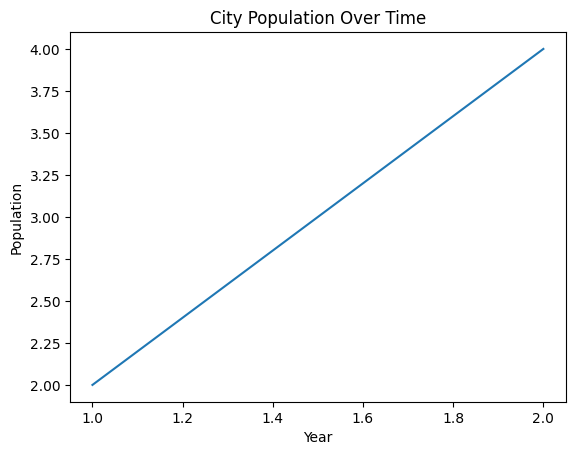

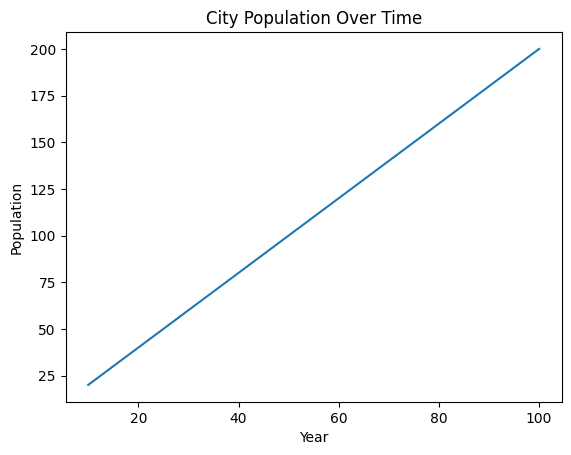

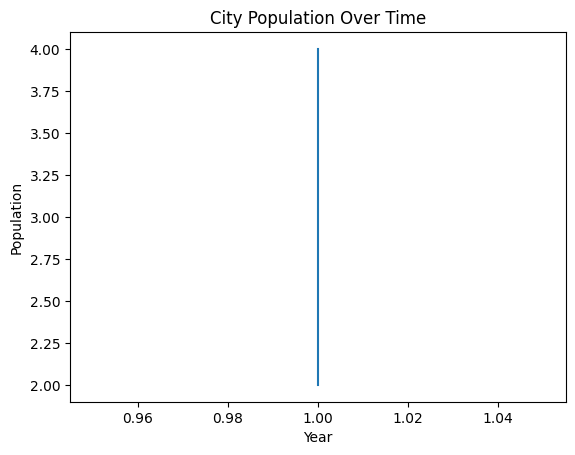

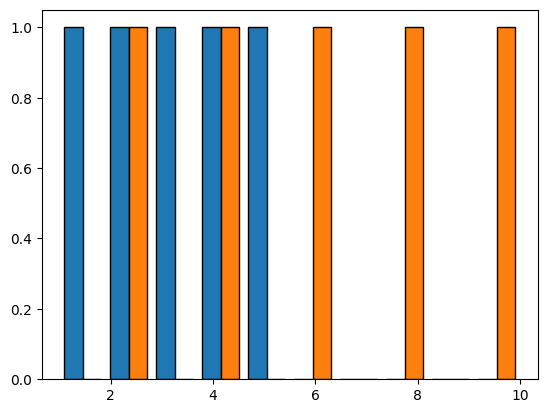

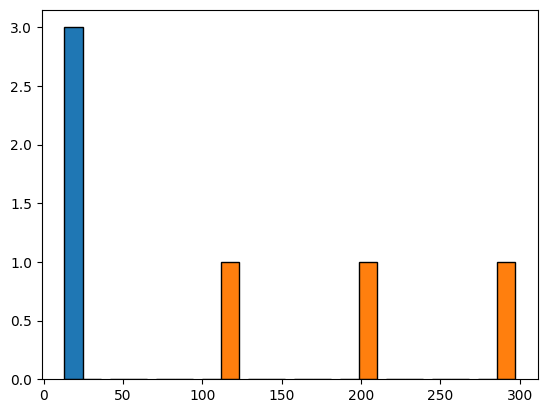

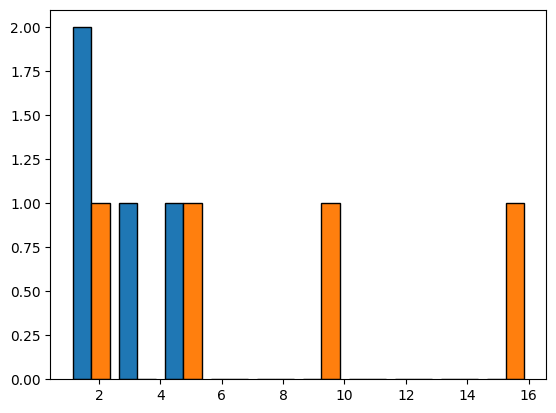

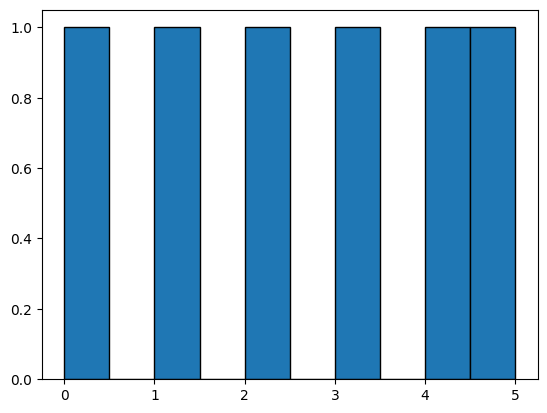

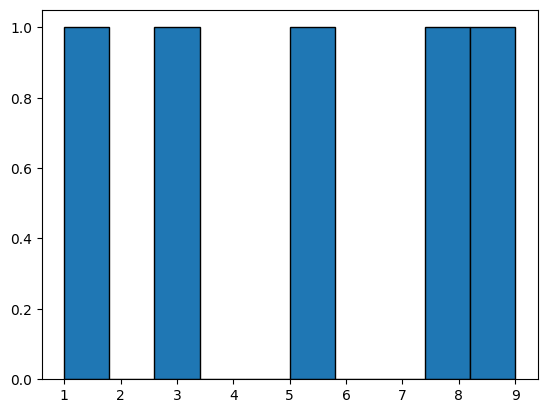

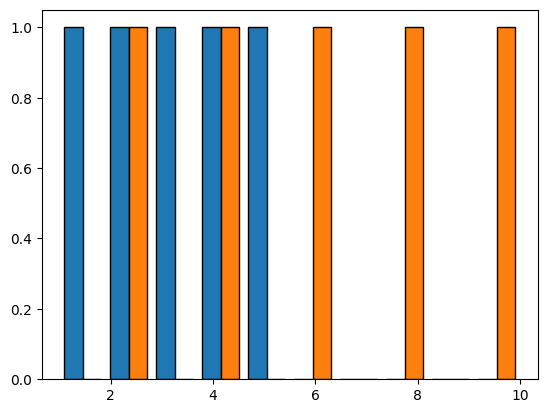

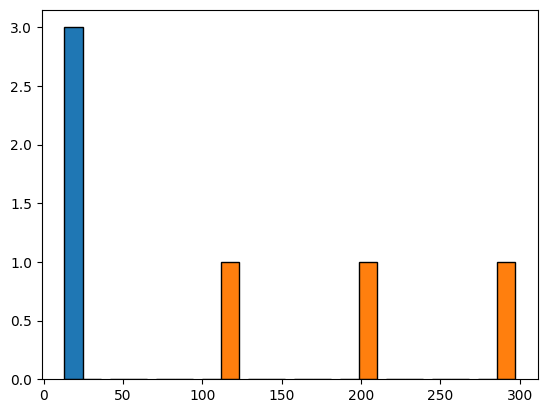

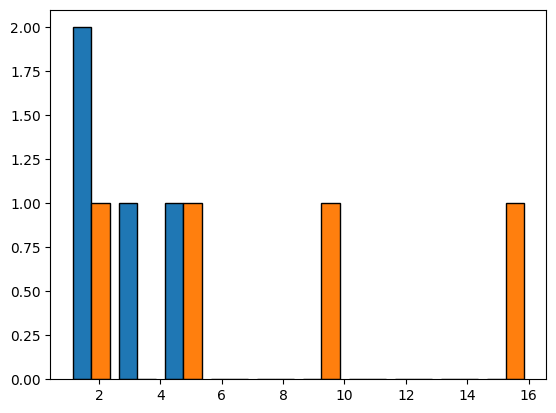

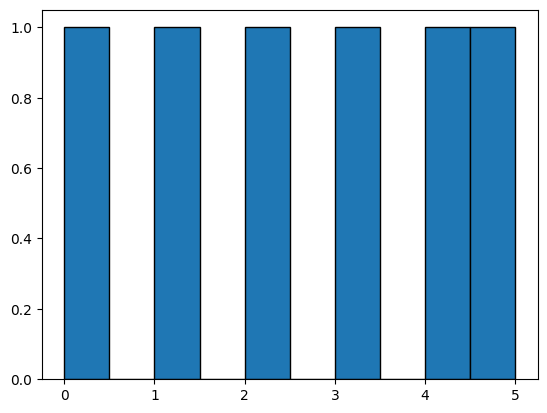

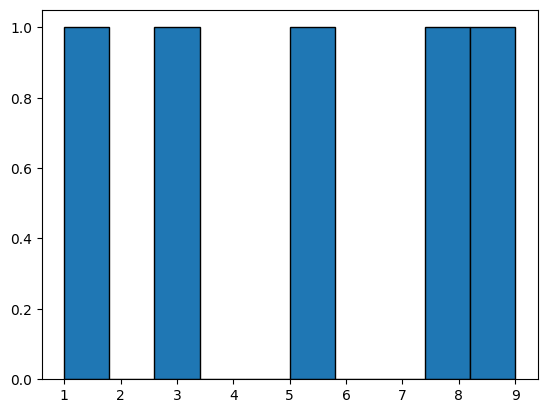


🏁 TEST GENERATION COMPLETE
  📥 Total read:      179
  ✅ Total augmented:  127
  ⏭️  Total skipped:   52
  📊 Augmentation rate: 70.9%
  ⏱️  Time: 2.2s (0.0m)
  📄 Output: stage2_buggy_pairs_with_tests.jsonl

  📋 Skip reasons (top 10):
        5x — <2 tests for intent=pandas_dataframe_creation
        5x — <2 tests for intent=pandas_data_filtering
        4x — <2 tests for intent=numpy_array_manipulation
        4x — <2 tests for intent=numpy_linear_algebra
        4x — <2 tests for intent=pandas_groupby_aggregation
        4x — <2 tests for intent=pandas_missing_data_handling
        4x — <2 tests for intent=torch_tensor_operations
        4x — <2 tests for intent=torch_neural_network_definition
        3x — <2 tests for intent=matrix_multiply
        3x — <2 tests for intent=torch_gradient_computation

  ✅ Verified: 127 samples with ≥2 tests in stage2_buggy_pairs_with_tests.jsonl


In [35]:
#!/usr/bin/env python3
"""
attach_intent_aware_tests.py
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Intent-aware test harness generator for the dataset distillation pipeline.

Reads:   stage2_buggy_pairs.jsonl
Writes:  stage2_buggy_pairs_with_tests.jsonl

For each sample, deterministically generates structured inputs based on the
intent string, executes the fixed_code's solve() function, captures outputs,
and attaches a "tests" list of {input, output} pairs. Samples with < 2 valid
tests are skipped.

No LLM calls. No multiprocessing. No randomness beyond seeded determinism.
"""

import json
import os
import sys
import ast
import inspect
import random
import time
import copy
import traceback
import math
from typing import Any, Dict, List, Optional, Tuple

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIGURATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

INPUT_FILE = "stage2_buggy_pairs.jsonl"
OUTPUT_FILE = "stage2_buggy_pairs_with_tests.jsonl"
MIN_TESTS_REQUIRED = 2
MAX_INPUT_ATTEMPTS = 5
EXEC_TIMEOUT_HINT = 3  # seconds (soft — no hard kill, just a guideline)
SEED = 42

random.seed(SEED)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# JSON SERIALIZATION UTILITIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def make_json_safe(obj: Any) -> Any:
    """
    Recursively convert an object into a JSON-serializable form.

    Handles: numpy arrays, numpy scalars, torch tensors, tuples,
    sets, bytes, and nested structures.
    """
    # ── numpy types ──
    try:
        import numpy as np
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.bool_):
            return bool(obj)
        if isinstance(obj, np.str_):
            return str(obj)
    except ImportError:
        pass

    # ── torch types ──
    try:
        import torch
        if isinstance(obj, torch.Tensor):
            return obj.detach().cpu().tolist()
    except ImportError:
        pass

    # ── pandas types ──
    try:
        import pandas as pd
        if isinstance(obj, pd.DataFrame):
            return obj.to_dict(orient='list')
        if isinstance(obj, pd.Series):
            return obj.tolist()
    except ImportError:
        pass

    # ── standard Python types ──
    if isinstance(obj, dict):
        return {make_json_safe(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list,)):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, set):
        return sorted([make_json_safe(x) for x in obj])
    if isinstance(obj, frozenset):
        return sorted([make_json_safe(x) for x in obj])
    if isinstance(obj, bytes):
        return obj.decode('utf-8', errors='replace')
    if isinstance(obj, (int, float, str, bool)):
        return obj
    if obj is None:
        return None

    # ── Fallback: try repr ──
    try:
        s = repr(obj)
        if len(s) < 500:
            return s
    except Exception:
        pass

    return str(obj)


def is_json_serializable(obj: Any) -> bool:
    """Check whether the object can be serialized to JSON after make_json_safe."""
    try:
        json.dumps(make_json_safe(obj))
        return True
    except (TypeError, ValueError, OverflowError):
        return False


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# INTENT-AWARE INPUT GENERATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Each generator returns a list of input-tuples. Each tuple is one set of
# arguments to pass to solve(*args). We generate multiple variants per intent
# so that at least MIN_TESTS_REQUIRED succeed.

def _int_list(seed_offset: int, length: int = 6) -> list:
    """Deterministic non-empty list of ints."""
    rng = random.Random(SEED + seed_offset)
    return [rng.randint(-50, 50) for _ in range(length)]


def _positive_int_list(seed_offset: int, length: int = 6) -> list:
    """Deterministic non-empty list of positive ints."""
    rng = random.Random(SEED + seed_offset)
    return [rng.randint(1, 100) for _ in range(length)]


def _sorted_list(seed_offset: int, length: int = 8) -> list:
    """Deterministic sorted list of ints."""
    lst = _int_list(seed_offset, length)
    return sorted(lst)


def _string(seed_offset: int, length: int = 8) -> str:
    """Deterministic alphabetic string."""
    rng = random.Random(SEED + seed_offset)
    return ''.join(rng.choice('abcdefghijklmnopqrstuvwxyz') for _ in range(length))


def _small_dict(seed_offset: int) -> dict:
    """Deterministic small dict."""
    rng = random.Random(SEED + seed_offset)
    keys = [chr(ord('a') + i) for i in range(rng.randint(2, 5))]
    return {k: rng.randint(1, 20) for k in keys}


def _nested_list(seed_offset: int) -> list:
    """Deterministic nested list for flattening."""
    rng = random.Random(SEED + seed_offset)
    return [[rng.randint(1, 10) for _ in range(rng.randint(1, 3))] for _ in range(rng.randint(2, 4))]


# ── Pure Python intent generators ──

PURE_PYTHON_GENERATORS = {
    'sort_list': lambda i: [
        (_int_list(i * 10 + 0, 5),),
        (_int_list(i * 10 + 1, 8),),
        (_int_list(i * 10 + 2, 3),),
        ([1],),
        ([5, 3, 1, 4, 2],),
    ],
    'reverse_string': lambda i: [
        (_string(i * 10 + 0, 6),),
        (_string(i * 10 + 1, 10),),
        ('hello',),
        ('a',),
        ('racecar',),
    ],
    'find_maximum': lambda i: [
        (_int_list(i * 10 + 0, 5),),
        (_int_list(i * 10 + 1, 8),),
        (_positive_int_list(i * 10 + 2, 4),),
        ([42],),
        ([1, 2, 3, 4, 5],),
    ],
    'find_minimum': lambda i: [
        (_int_list(i * 10 + 0, 5),),
        (_int_list(i * 10 + 1, 8),),
        (_positive_int_list(i * 10 + 2, 4),),
        ([42],),
        ([5, 4, 3, 2, 1],),
    ],
    'count_occurrences': lambda i: [
        ([1, 2, 3, 2, 1, 2], 2),
        ([5, 5, 5], 5),
        ([1, 2, 3], 4),
        (_int_list(i * 10 + 0, 8), _int_list(i * 10 + 0, 8)[0]),
        ('abracadabra', 'a'),
    ],
    'remove_duplicates': lambda i: [
        ([1, 2, 2, 3, 3, 3],),
        (_int_list(i * 10 + 0, 8),),
        ([1, 1, 1],),
        ([1, 2, 3],),
        ([],),
    ],
    'flatten_list': lambda i: [
        (_nested_list(i * 10 + 0),),
        ([[1, 2], [3, 4], [5]],),
        ([[1], [2], [3]],),
        ([[], [1, 2], []],),
        ([[1, [2, 3]], [4]],),
    ],
    'merge_dicts': lambda i: [
        (_small_dict(i * 10 + 0), _small_dict(i * 10 + 1)),
        ({'a': 1, 'b': 2}, {'c': 3, 'd': 4}),
        ({'x': 10}, {'x': 20}),
        ({}, {'a': 1}),
        ({'a': 1}, {}),
    ],
    'fibonacci_sequence': lambda i: [
        (5,),
        (10,),
        (1,),
        (8,),
        (12,),
    ],
    'factorial_computation': lambda i: [
        (5,),
        (0,),
        (1,),
        (7,),
        (10,),
    ],
    'is_palindrome': lambda i: [
        ('racecar',),
        ('hello',),
        ('madam',),
        ('a',),
        ('ab',),
    ],
    'binary_search': lambda i: [
        (_sorted_list(i * 10 + 0, 8), _sorted_list(i * 10 + 0, 8)[3]),
        ([1, 3, 5, 7, 9, 11], 7),
        ([1, 3, 5, 7, 9, 11], 4),
        ([2, 4, 6, 8], 2),
        ([10], 10),
    ],
    'gcd_computation': lambda i: [
        (12, 8),
        (100, 75),
        (17, 13),
        (48, 36),
        (7, 7),
    ],
    'lcm_computation': lambda i: [
        (4, 6),
        (12, 15),
        (7, 3),
        (10, 5),
        (8, 12),
    ],
    'prime_check': lambda i: [
        (7,),
        (4,),
        (2,),
        (13,),
        (1,),
    ],
    'matrix_multiply': lambda i: [
        ([[1, 2], [3, 4]], [[5, 6], [7, 8]]),
        ([[1, 0], [0, 1]], [[3, 4], [5, 6]]),
        ([[2, 3, 4]], [[1], [2], [3]]),
        ([[1, 2, 3], [4, 5, 6]], [[7, 8], [9, 10], [11, 12]]),
        ([[1]], [[1]]),
    ],
    'transpose_matrix': lambda i: [
        ([[1, 2, 3], [4, 5, 6]],),
        ([[1, 2], [3, 4]],),
        ([[1]],),
        ([[1, 2, 3]],),
        ([[1], [2], [3]],),
    ],
    'string_compression': lambda i: [
        ('aabcccccaaa',),
        ('abcdef',),
        ('aaa',),
        ('aabbcc',),
        ('a',),
    ],
    'anagram_check': lambda i: [
        ('listen', 'silent'),
        ('hello', 'world'),
        ('triangle', 'integral'),
        ('abc', 'cba'),
        ('aab', 'aba'),
    ],
    'caesar_cipher': lambda i: [
        ('hello', 3),
        ('abc', 1),
        ('xyz', 3),
        ('HELLO', 5),
        ('test', 13),
    ],
    'valid_parentheses': lambda i: [
        ('(())',),
        ('()',),
        ('(()',),
        (')(', ),
        ('({[]})',),
    ],
    'two_sum': lambda i: [
        ([2, 7, 11, 15], 9),
        ([3, 2, 4], 6),
        ([1, 5, 3, 7], 8),
        ([1, 2, 3, 4, 5], 9),
        ([0, 4, 3, 0], 0),
    ],
    'longest_common_subsequence': lambda i: [
        ('abcde', 'ace'),
        ('abc', 'abc'),
        ('abc', 'def'),
        ('abcba', 'abcbcba'),
        ('oxcpqrsvwf', 'shmtulqrypy'),
    ],
    'knapsack_problem': lambda i: [
        ([60, 100, 120], [10, 20, 30], 50),
        ([10, 20, 30], [1, 2, 3], 5),
        ([1, 2, 3], [4, 5, 1], 4),
        ([5, 4, 3, 2], [4, 3, 2, 1], 6),
        ([7], [5], 5),
    ],
    'depth_first_search': lambda i: [
        ({0: [1, 2], 1: [3], 2: [4], 3: [], 4: []}, 0),
        ({0: [1], 1: [2], 2: [0]}, 0),
        ({0: [1, 2], 1: [], 2: [3], 3: []}, 0),
        ({'a': ['b', 'c'], 'b': ['d'], 'c': [], 'd': []}, 'a'),
        ({0: [], 1: [0]}, 0),
    ],
    'breadth_first_search': lambda i: [
        ({0: [1, 2], 1: [3], 2: [4], 3: [], 4: []}, 0),
        ({0: [1], 1: [2], 2: [0]}, 0),
        ({0: [1, 2], 1: [], 2: [3], 3: []}, 0),
        ({'a': ['b', 'c'], 'b': ['d'], 'c': [], 'd': []}, 'a'),
        ({0: [], 1: [0]}, 0),
    ],
}

# ── NumPy intent generators ──

def _numpy_generators(intent: str, idx: int) -> List[tuple]:
    """Generate inputs for numpy-based intents."""
    try:
        import numpy as np
    except ImportError:
        return []

    rng = random.Random(SEED + idx * 10)

    # Small deterministic arrays
    arr_2x3 = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float64)
    arr_3x3 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.float64)
    arr_3x2 = np.array([[1, 4], [2, 5], [3, 6]], dtype=np.float64)
    arr_1d = np.array([3.0, 1.0, 4.0, 1.0, 5.0, 9.0])
    arr_small = np.array([1.0, 2.0, 3.0])

    variants = [
        (arr_2x3,),
        (arr_3x3,),
        (arr_1d,),
        (arr_small,),
        (arr_3x2,),
    ]

    # For ops needing two arrays
    if any(kw in intent for kw in ['multiply', 'operations', 'algebra']):
        variants = [
            (arr_3x3, arr_3x3),
            (arr_2x3, arr_3x2),
            (arr_3x3,),
            (np.eye(3),),
            (arr_1d,),
        ]

    return variants


# ── Pandas intent generators ──

def _pandas_generators(intent: str, idx: int) -> List[tuple]:
    """Generate inputs for pandas-based intents."""
    try:
        import pandas as pd
    except ImportError:
        return []

    df1 = pd.DataFrame({
        'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
        'age': [25, 30, 35, 28, 22],
        'salary': [50000, 60000, 70000, 55000, 45000],
        'department': ['eng', 'eng', 'sales', 'sales', 'eng'],
    })

    df2 = pd.DataFrame({
        'x': [1, 2, 3, 4, 5],
        'y': [10, 20, 30, 40, 50],
        'category': ['a', 'b', 'a', 'b', 'a'],
    })

    df3 = pd.DataFrame({
        'value': [1.0, None, 3.0, None, 5.0],
        'label': ['x', 'y', 'x', 'y', 'x'],
    })

    df4 = pd.DataFrame({
        'score': [88, 92, 75, 60, 95],
        'grade': ['B', 'A', 'C', 'D', 'A'],
    })

    return [
        (df1,),
        (df2,),
        (df3,),
        (df4,),
        (df1.copy(),),
    ]


# ── Torch intent generators ──

def _torch_generators(intent: str, idx: int) -> List[tuple]:
    """Generate inputs for torch-based intents. CPU only."""
    try:
        import torch
    except ImportError:
        return []

    t1 = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
    t2 = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
    t3 = torch.randn(3, 4)
    t_1d = torch.tensor([1.0, 2.0, 3.0, 4.0])

    if 'loss' in intent:
        # predictions and targets for loss
        pred = torch.tensor([0.8, 0.2, 0.6, 0.9])
        target = torch.tensor([1.0, 0.0, 1.0, 1.0])
        pred2 = torch.randn(5, 3)
        target2 = torch.tensor([0, 1, 2, 0, 1])
        return [
            (pred, target),
            (t_1d, t_1d),
            (pred2, target2),
            (torch.sigmoid(torch.randn(4)), torch.tensor([1.0, 0.0, 1.0, 0.0])),
            (torch.randn(3), torch.ones(3)),
        ]

    if 'gradient' in intent:
        x = torch.tensor([2.0, 3.0], requires_grad=True)
        return [
            (x,),
            (torch.tensor([1.0, 4.0, 9.0], requires_grad=True),),
            (torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True),),
            (torch.tensor([5.0], requires_grad=True),),
            (torch.randn(3, 3, requires_grad=True),),
        ]

    if 'neural' in intent or 'network' in intent:
        # simple input batch
        batch1 = torch.randn(4, 10)
        batch2 = torch.randn(2, 5)
        batch3 = torch.randn(8, 10)
        return [
            (batch1,),
            (batch2,),
            (batch3,),
            (torch.randn(1, 10),),
            (torch.randn(3, 10),),
        ]

    return [
        (t1,),
        (t2,),
        (t1, t2),
        (t3,),
        (t_1d,),
    ]


# ── Sklearn intent generators ──

def _sklearn_generators(intent: str, idx: int) -> List[tuple]:
    """Generate inputs for sklearn-based intents. Tiny synthetic data only."""
    try:
        import numpy as np
    except ImportError:
        return []

    rng = np.random.RandomState(SEED + idx)

    # Tiny classification dataset
    X_cls = rng.randn(20, 4)
    y_cls = (rng.rand(20) > 0.5).astype(int)

    # Tiny regression dataset
    X_reg = rng.randn(20, 3)
    y_reg = X_reg[:, 0] * 2.0 + X_reg[:, 1] * 0.5 + rng.randn(20) * 0.1

    # Tiny clustering dataset
    X_clust = np.vstack([
        rng.randn(10, 2) + np.array([2, 2]),
        rng.randn(10, 2) + np.array([-2, -2]),
    ])

    # Preprocessing data
    X_pre = rng.randn(15, 5)

    variants = [
        (X_cls, y_cls),
        (X_reg, y_reg),
        (X_clust,),
        (X_pre,),
        (X_cls[:10], y_cls[:10]),
    ]

    # For classification/regression, ensure X, y pairs
    if 'classification' in intent or 'regression' in intent:
        variants = [
            (X_cls, y_cls),
            (X_reg, y_reg),
            (X_cls[:10], y_cls[:10]),
            (X_reg[:10], y_reg[:10]),
            (rng.randn(15, 4), (rng.rand(15) > 0.5).astype(int)),
        ]
    elif 'clustering' in intent:
        variants = [
            (X_clust,),
            (X_cls,),
            (rng.randn(30, 2),),
            (X_pre[:, :2],),
            (rng.randn(20, 3),),
        ]
    elif 'preprocessing' in intent:
        variants = [
            (X_pre,),
            (X_cls,),
            (rng.randn(10, 6),),
            (X_reg,),
            (rng.randn(25, 3),),
        ]

    return variants


# ── Matplotlib intent generators (output validation is lenient) ──

def _matplotlib_generators(intent: str, idx: int) -> List[tuple]:
    """Generate inputs for matplotlib-based intents."""
    variants = [
        ([1, 2, 3, 4, 5], [2, 4, 6, 8, 10]),
        ([10, 20, 30], [100, 200, 300]),
        ([1, 2, 3, 4], [1, 4, 9, 16]),
        ([0, 1, 2, 3, 4, 5],),
        ([5, 3, 8, 1, 9],),
    ]
    return [v if isinstance(v, tuple) else (v,) for v in variants]


# ── Datasets intent generators ──

def _datasets_generators(intent: str, idx: int) -> List[tuple]:
    """Generate inputs for HF datasets intents — typically no args or string args."""
    return [
        (),
        ('text',),
        ('train',),
        (),
        (),
    ]


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# INTENT → INPUT DISPATCH
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def _detect_category(intent: str) -> str:
    """Detect the high-level category from the intent string."""
    intent_lower = intent.lower()
    if intent_lower.startswith('numpy_') or 'numpy' in intent_lower:
        return 'numpy'
    if intent_lower.startswith('pandas_') or 'pandas' in intent_lower:
        return 'pandas'
    if intent_lower.startswith('torch_') or 'torch' in intent_lower:
        return 'torch'
    if intent_lower.startswith('sklearn_') or 'sklearn' in intent_lower:
        return 'sklearn'
    if intent_lower.startswith('matplotlib_') or 'matplotlib' in intent_lower:
        return 'matplotlib'
    if intent_lower.startswith('datasets_') or 'datasets' in intent_lower:
        return 'datasets'
    return 'pure_python'


def generate_inputs_from_intent(intent: str, sig: inspect.Signature, idx: int) -> List[tuple]:
    """
    Generate a list of input-tuples for the given intent and function signature.

    Returns up to MAX_INPUT_ATTEMPTS input variants. Each variant is a tuple
    of arguments to pass to solve(*args).
    """
    n_params = len([
        p for p in sig.parameters.values()
        if p.default is inspect.Parameter.empty
        and p.kind in (inspect.Parameter.POSITIONAL_ONLY,
                        inspect.Parameter.POSITIONAL_OR_KEYWORD)
    ])

    category = _detect_category(intent)

    # ── Try category-specific generators first ──
    if category == 'numpy':
        variants = _numpy_generators(intent, idx)
    elif category == 'pandas':
        variants = _pandas_generators(intent, idx)
    elif category == 'torch':
        variants = _torch_generators(intent, idx)
    elif category == 'sklearn':
        variants = _sklearn_generators(intent, idx)
    elif category == 'matplotlib':
        variants = _matplotlib_generators(intent, idx)
    elif category == 'datasets':
        variants = _datasets_generators(intent, idx)
    else:
        # Pure Python — look up specific generator
        gen_fn = PURE_PYTHON_GENERATORS.get(intent)
        if gen_fn is not None:
            variants = gen_fn(idx)
        else:
            # Fallback: generate generic inputs based on param count
            variants = _generic_fallback(n_params, idx)

    # ── Filter variants to match arity ──
    # If the function has *args or **kwargs, accept any arity
    has_var_positional = any(
        p.kind == inspect.Parameter.VAR_POSITIONAL
        for p in sig.parameters.values()
    )
    has_var_keyword = any(
        p.kind == inspect.Parameter.VAR_KEYWORD
        for p in sig.parameters.values()
    )

    if not has_var_positional and not has_var_keyword:
        # Try to match arity, but also allow if total params (incl defaults) match
        total_params = len(sig.parameters)
        filtered = []
        for v in variants:
            if not isinstance(v, tuple):
                v = (v,)
            if n_params <= len(v) <= total_params:
                filtered.append(v)
            elif len(v) == 1 and n_params == 0:
                # Maybe the function takes no args — try empty
                pass
            elif n_params == 1 and len(v) > 1:
                # Try wrapping all args as a single collection arg
                filtered.append((list(v),))
        if filtered:
            variants = filtered
    else:
        # Accept all variants
        variants = [v if isinstance(v, tuple) else (v,) for v in variants]

    # Ensure we have at least some attempts
    if not variants:
        variants = _generic_fallback(n_params, idx)

    return variants[:MAX_INPUT_ATTEMPTS]


def _generic_fallback(n_params: int, idx: int) -> List[tuple]:
    """
    Generate generic fallback inputs when no intent-specific generator exists.
    Based on parameter count alone.
    """
    rng = random.Random(SEED + idx * 100)

    if n_params == 0:
        return [()]
    elif n_params == 1:
        return [
            (_int_list(idx * 10 + 0, 5),),
            (_string(idx * 10 + 1, 6),),
            (rng.randint(1, 20),),
            ([1, 2, 3, 4, 5],),
            ({'a': 1, 'b': 2},),
        ]
    elif n_params == 2:
        return [
            (_int_list(idx * 10 + 0, 5), _int_list(idx * 10 + 1, 5)),
            (_string(idx * 10 + 2, 6), _string(idx * 10 + 3, 6)),
            (rng.randint(1, 20), rng.randint(1, 20)),
            ([1, 2, 3], [4, 5, 6]),
            (_small_dict(idx * 10 + 4), _small_dict(idx * 10 + 5)),
        ]
    elif n_params == 3:
        return [
            (_int_list(idx * 10 + 0, 5), rng.randint(1, 10), rng.randint(1, 10)),
            ([1, 2, 3], [4, 5, 6], [7, 8, 9]),
            (rng.randint(1, 10), rng.randint(1, 10), rng.randint(1, 10)),
            ([10, 20, 30], [1, 2, 3], 5),
            (_string(idx * 10, 4), _string(idx * 10 + 1, 4), rng.randint(1, 5)),
        ]
    else:
        # n >= 4: generate n random args each time
        variants = []
        for v in range(MAX_INPUT_ATTEMPTS):
            args = tuple(rng.randint(1, 20) for _ in range(n_params))
            variants.append(args)
        return variants


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SAFE EXECUTION ENGINE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def _extract_solve_function(code: str) -> Optional[callable]:
    """
    Execute code in an isolated namespace and extract the 'solve' function.
    Returns the callable or None if extraction fails.
    """
    # Verify AST has exactly one top-level function named 'solve'
    try:
        tree = ast.parse(code)
    except SyntaxError:
        return None

    top_funcs = [
        n for n in ast.iter_child_nodes(tree)
        if isinstance(n, ast.FunctionDef)
    ]
    solve_funcs = [f for f in top_funcs if f.name == 'solve']
    if len(solve_funcs) != 1:
        return None

    # Execute in isolated namespace
    ns = {}
    try:
        exec(compile(code, '<test_harness>', 'exec'), ns)
    except Exception:
        return None

    fn = ns.get('solve')
    if fn is None or not callable(fn):
        return None

    return fn


def _safe_call(fn: callable, args: tuple) -> Tuple[bool, Any]:
    """
    Call fn(*args) safely. Returns (success, result_or_error).
    Handles exceptions, infinite values, NaN, etc.
    """
    try:
        result = fn(*args)
    except Exception as e:
        return False, f"{type(e).__name__}: {str(e)[:200]}"

    # Check for non-JSON-safe results
    if result is None:
        # None is valid JSON
        return True, None

    if not is_json_serializable(result):
        return False, "Result not JSON-serializable"

    return True, result


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MAIN TEST GENERATION LOGIC
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def try_generate_tests(sample: dict, idx: int) -> Optional[List[dict]]:
    """
    Attempt to generate test cases for a single sample.

    1. Extract solve() from fixed_code
    2. Get its signature
    3. Generate intent-aware inputs
    4. Execute and capture outputs
    5. Return list of {input, output} dicts, or None if < MIN_TESTS_REQUIRED

    Args:
        sample: dict with 'intent', 'fixed_code', 'buggy_code', etc.
        idx: sample index (for deterministic seeding)

    Returns:
        List of test dicts or None if insufficient tests generated.
    """
    intent = sample.get('intent', '')
    fixed_code = sample.get('fixed_code', '')

    if not fixed_code.strip():
        return None

    # ── Step 1: Extract solve function ──
    solve_fn = _extract_solve_function(fixed_code)
    if solve_fn is None:
        return None

    # ── Step 2: Get signature ──
    try:
        sig = inspect.signature(solve_fn)
    except (ValueError, TypeError):
        return None

    # ── Step 3: Generate inputs ──
    input_variants = generate_inputs_from_intent(intent, sig, idx)

    # ── Step 4: Execute each variant and collect results ──
    tests = []
    for args in input_variants:
        if not isinstance(args, tuple):
            args = (args,)

        # Deep-copy inputs to avoid mutation during execution
        try:
            safe_args = copy.deepcopy(args)
        except Exception:
            safe_args = args

        success, result = _safe_call(solve_fn, safe_args)

        if not success:
            continue

        # Convert inputs and output to JSON-safe format
        try:
            json_input = make_json_safe(args)
            json_output = make_json_safe(result)

            # Final sanity check: can we actually serialize?
            json.dumps(json_input)
            json.dumps(json_output)

            tests.append({
                "input": json_input,
                "output": json_output,
            })
        except (TypeError, ValueError, OverflowError):
            continue

        # Stop early if we have enough
        if len(tests) >= MAX_INPUT_ATTEMPTS:
            break

    # ── Step 5: Check minimum threshold ──
    if len(tests) < MIN_TESTS_REQUIRED:
        return None

    return tests


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PIPELINE ENTRY POINT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def main():
    """
    Main pipeline:
    1. Read stage2_buggy_pairs.jsonl
    2. For each sample, generate intent-aware tests from fixed_code
    3. Attach tests and write to output
    4. Print final statistics
    """
    print("=" * 70)
    print("🧪 INTENT-AWARE TEST HARNESS GENERATOR")
    print("=" * 70)

    # ── Validate input ──
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Input file not found: {INPUT_FILE}")
        sys.exit(1)

    # ── Load samples ──
    samples = []
    with open(INPUT_FILE, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                samples.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"  ⚠️  Skipped malformed JSON at line {line_num}")

    total_read = len(samples)
    print(f"\n📥 Loaded {total_read} samples from {INPUT_FILE}")

    if total_read == 0:
        print("❌ No samples to process.")
        sys.exit(1)

    # ── Process samples ──
    augmented = 0
    skipped = 0
    skip_reasons = {}
    t_start = time.time()

    # Truncate output file (fresh write)
    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
        pass

    for idx, sample in enumerate(samples):
        intent = sample.get('intent', '?')

        tests = try_generate_tests(sample, idx)

        if tests is None:
            skipped += 1
            reason = f"<{MIN_TESTS_REQUIRED} tests for intent={intent}"
            skip_reasons[reason] = skip_reasons.get(reason, 0) + 1

            if skipped <= 5:
                print(f"  ⏭️  [{idx+1}/{total_read}] Skipped: {intent}")
            continue

        # Attach tests to sample
        out = {**sample, 'tests': tests}
        with open(OUTPUT_FILE, 'a', encoding='utf-8') as f:
            f.write(json.dumps(out, ensure_ascii=False) + '\n')

        augmented += 1

        # Progress reporting
        if augmented % 100 == 0 or augmented <= 3:
            elapsed = time.time() - t_start
            rate = augmented / elapsed if elapsed > 0 else 0
            eta = (total_read - idx - 1) / rate if rate > 0 else 0
            avg_tests = sum(len(t.get('tests', [])) for t in [out]) / 1
            print(
                f"  ✅ [{idx+1}/{total_read}] {intent[:30]} "
                f"| {len(tests)} tests "
                f"| {rate:.1f}/s "
                f"| ETA: {eta/60:.1f}m"
            )

    # ── Final statistics ──
    elapsed = time.time() - t_start
    print(f"\n{'=' * 70}")
    print(f"🏁 TEST GENERATION COMPLETE")
    print(f"{'=' * 70}")
    print(f"  📥 Total read:      {total_read}")
    print(f"  ✅ Total augmented:  {augmented}")
    print(f"  ⏭️  Total skipped:   {skipped}")
    print(f"  📊 Augmentation rate: {augmented/max(total_read,1)*100:.1f}%")
    print(f"  ⏱️  Time: {elapsed:.1f}s ({elapsed/60:.1f}m)")
    print(f"  📄 Output: {OUTPUT_FILE}")

    if skip_reasons:
        print(f"\n  📋 Skip reasons (top 10):")
        for reason, count in sorted(skip_reasons.items(), key=lambda x: -x[1])[:10]:
            print(f"     {count:4d}x — {reason}")

    # ── Verify output ──
    out_count = 0
    if os.path.exists(OUTPUT_FILE):
        with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    try:
                        obj = json.loads(line.strip())
                        if 'tests' in obj and len(obj['tests']) >= MIN_TESTS_REQUIRED:
                            out_count += 1
                    except:
                        pass

    print(f"\n  ✅ Verified: {out_count} samples with ≥{MIN_TESTS_REQUIRED} tests in {OUTPUT_FILE}")
    print(f"{'=' * 70}")


if __name__ == '__main__':
    main()


---
# 🧪 Stage 3 — Execution Validation

Sandboxed execution of fixed vs buggy code. Keeps only **contrastive pairs** (fixed passes, buggy fails).
Saves to `stage3_validated_pairs.jsonl`.


🧪 BEHAVIORAL CONTRAST VALIDATOR

📥 Loaded 127 samples from stage2_buggy_pairs_with_tests.jsonl
  [    1/127] valid=   1 both_pass=   0 both_fail=   0 | 1313.2/s | ETA: 0.0m
    ✅ PASS: sort_list (5 tests)
  [    2/127] valid=   2 both_pass=   0 both_fail=   0 | 1434.9/s | ETA: 0.0m
    ✅ PASS: sort_list (5 tests)
  [    3/127] valid=   3 both_pass=   0 both_fail=   0 | 1439.9/s | ETA: 0.0m
    ✅ PASS: sort_list (5 tests)
  [    4/127] valid=   4 both_pass=   0 both_fail=   0 | 1480.5/s | ETA: 0.0m
  [    5/127] valid=   5 both_pass=   0 both_fail=   0 | 1438.2/s | ETA: 0.0m
    ⏭️  both-pass: two_sum
    ⏭️  both-pass: two_sum
    ⏭️  both-pass: longest_common_subsequence
    ⏭️  both-fail: torch_loss_computation
    ⏭️  both-fail: torch_loss_computation
    ⏭️  both-fail: torch_loss_computation


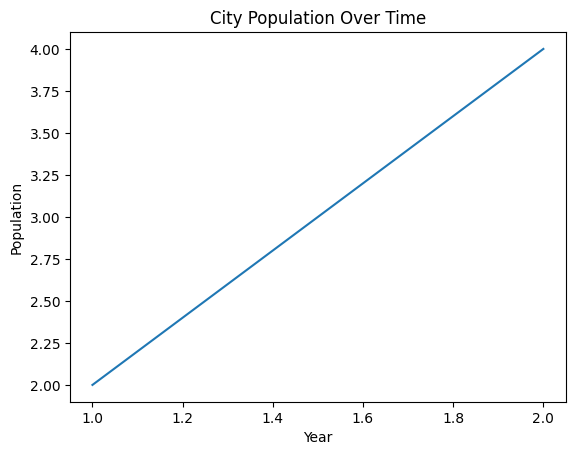

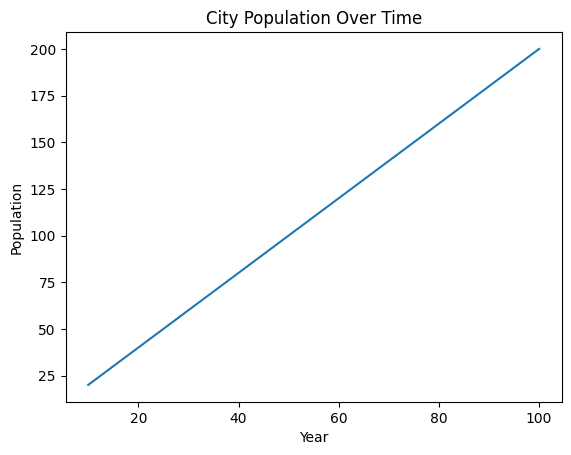

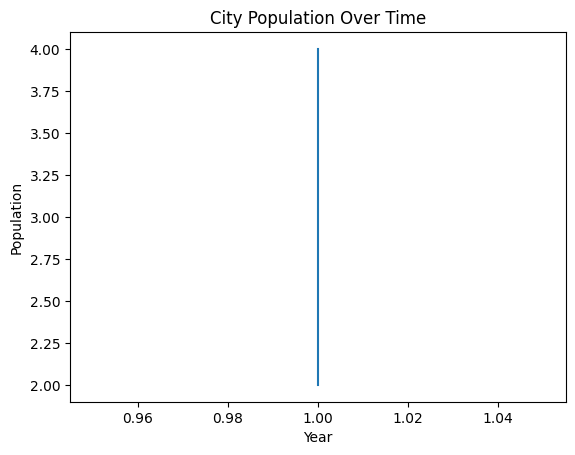

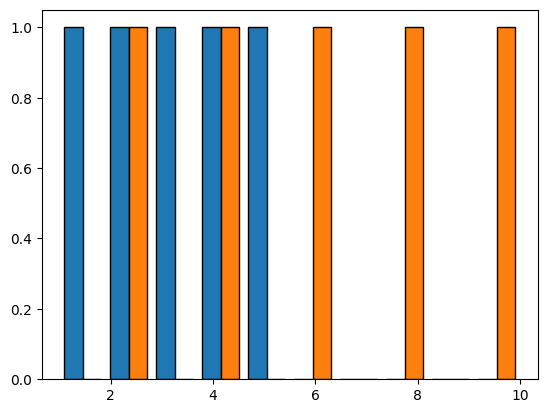

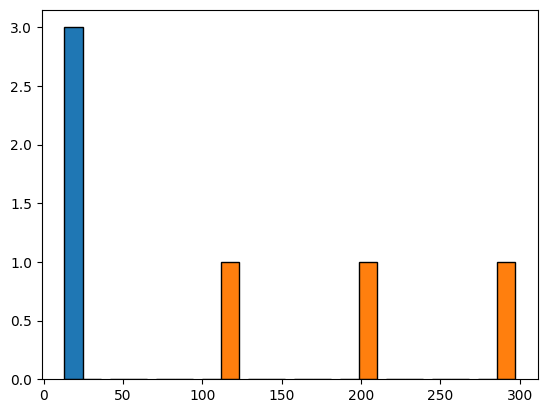

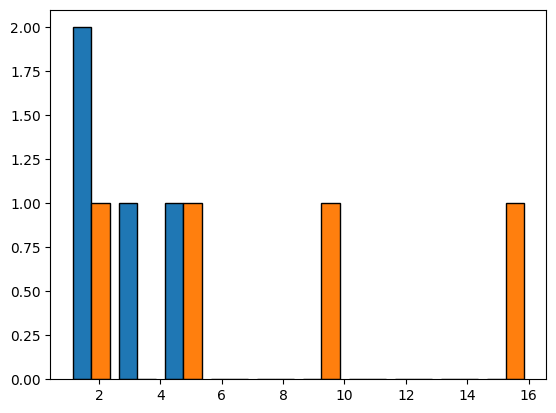

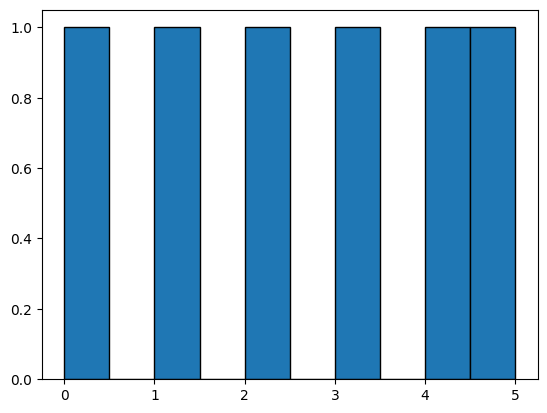

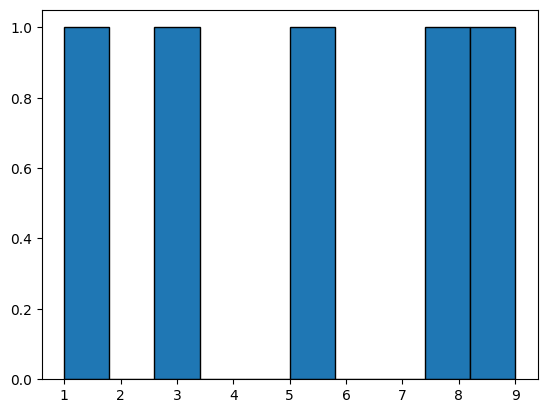

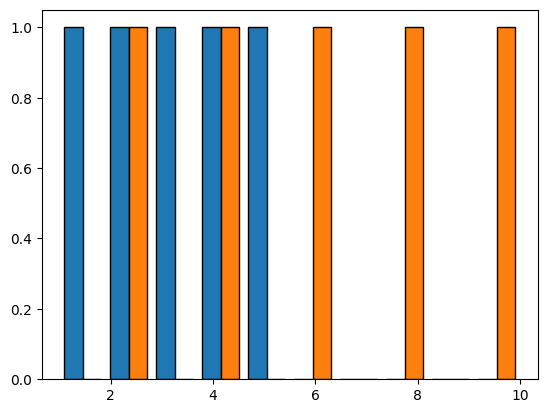

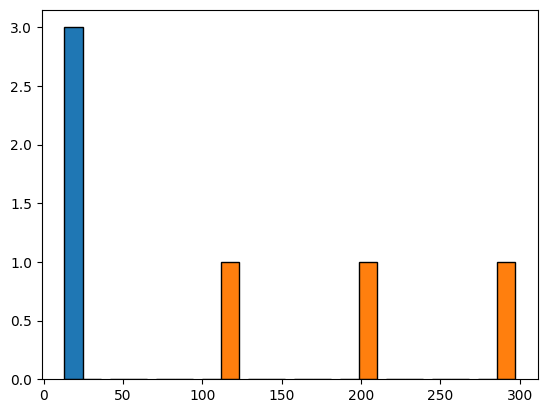

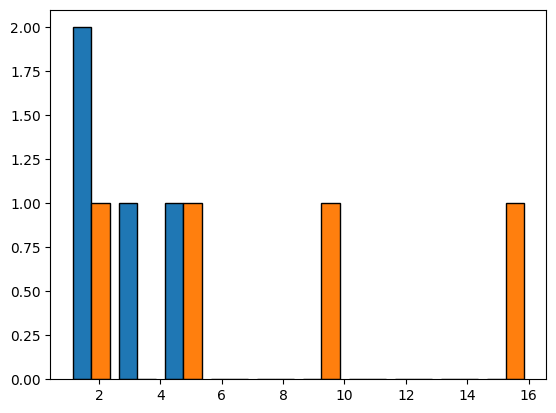

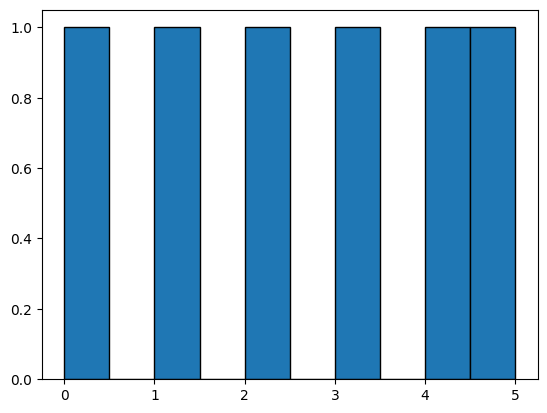

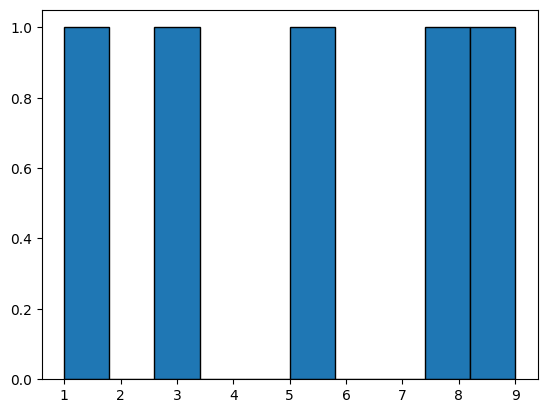

  [  127/127] valid= 121 both_pass=   3 both_fail=   3 | 82.9/s | ETA: 0.0m

🏁 BEHAVIORAL CONTRAST VALIDATION COMPLETE
  📥 Total samples:          127
  ✅ Contrastive valid pairs: 121
  ⏭️  Both pass (discarded):  3
  ⏭️  Both fail (discarded):  3
  🔄 Inverted (discarded):   0
  ⚠️  No tests (discarded):   0
  ⚠️  No code (discarded):    0
  ❌ Errors:                  0
  📊 Contrastive rate:       95.3%
  ⏱️  Time:                   1.5s (0.0m)
  📄 Saved to:               stage3_validated_pairs.jsonl

  ✅ Verified: 121 valid JSONL lines in stage3_validated_pairs.jsonl
  ✅ Assertion passed: 121 contrastive pairs confirmed.


In [36]:
#!/usr/bin/env python3
"""
behavioral_contrast_validator.py
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Behavioral contrast validation for the dataset distillation pipeline.

Reads:   stage2_buggy_pairs_with_tests.jsonl
Writes:  stage3_validated_pairs.jsonl

For each sample, executes both fixed_code and buggy_code against all attached
test cases. Keeps only contrastive pairs where fixed passes ALL tests and
buggy fails AT LEAST one test. All outputs are normalized and compared with
floating-point tolerance for robust cross-type equality.

No multiprocessing. No sandboxing. Deterministic. Scales to 20k samples.
"""

import json
import os
import sys
import ast
import time
import math
import traceback
from typing import Any, Dict, List, Optional, Tuple

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIGURATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

INPUT_FILE = "stage2_buggy_pairs_with_tests.jsonl"
OUTPUT_FILE = "stage3_validated_pairs.jsonl"
FLOAT_TOLERANCE = 1e-6

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OPTIONAL IMPORTS (numpy / torch — only if available)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

_HAS_NUMPY = False
_HAS_TORCH = False
_HAS_PANDAS = False

try:
    import numpy as np
    _HAS_NUMPY = True
except ImportError:
    np = None

try:
    import torch
    _HAS_TORCH = True
except ImportError:
    torch = None

try:
    import pandas as pd
    _HAS_PANDAS = True
except ImportError:
    pd = None


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OUTPUT NORMALIZATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def normalize_output(obj: Any) -> Any:
    """
    Recursively convert an output object into a canonical, comparable form.

    Conversion rules:
        - torch.Tensor  → .detach().cpu().tolist()  → then recurse
        - numpy.ndarray → .tolist()                 → then recurse
        - numpy scalar  → .item()                   (int/float)
        - pandas DataFrame → .to_dict(orient='list') → then recurse
        - pandas Series    → .tolist()               → then recurse
        - tuple         → list                       → then recurse
        - set/frozenset → sorted list               → then recurse
        - dict          → recurse on keys and values
        - list          → recurse on elements
        - bytes         → decode to str
        - int/float/str/bool/None → pass through
    """
    # ── torch.Tensor ──
    if _HAS_TORCH and isinstance(obj, torch.Tensor):
        return normalize_output(obj.detach().cpu().tolist())

    # ── numpy.ndarray ──
    if _HAS_NUMPY and isinstance(obj, np.ndarray):
        return normalize_output(obj.tolist())

    # ── numpy scalar types ──
    if _HAS_NUMPY:
        if isinstance(obj, (np.integer,)):
            return int(obj.item())
        if isinstance(obj, (np.floating,)):
            return float(obj.item())
        if isinstance(obj, np.bool_):
            return bool(obj.item())
        if isinstance(obj, np.str_):
            return str(obj)

    # ── pandas types ──
    if _HAS_PANDAS:
        if isinstance(obj, pd.DataFrame):
            return normalize_output(obj.to_dict(orient='list'))
        if isinstance(obj, pd.Series):
            return normalize_output(obj.tolist())

    # ── tuple → list ──
    if isinstance(obj, tuple):
        return [normalize_output(x) for x in obj]

    # ── set / frozenset → sorted list ──
    if isinstance(obj, (set, frozenset)):
        try:
            return sorted([normalize_output(x) for x in obj])
        except TypeError:
            return [normalize_output(x) for x in obj]

    # ── dict → recurse ──
    if isinstance(obj, dict):
        return {normalize_output(k): normalize_output(v) for k, v in obj.items()}

    # ── list → recurse ──
    if isinstance(obj, list):
        return [normalize_output(x) for x in obj]

    # ── bytes → str ──
    if isinstance(obj, bytes):
        return obj.decode('utf-8', errors='replace')

    # ── primitives ──
    if isinstance(obj, (int, float, str, bool)) or obj is None:
        return obj

    # ── fallback: try converting to a basic type ──
    try:
        return normalize_output(str(obj))
    except Exception:
        return str(obj)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OUTPUT COMPARISON
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def outputs_equal(a: Any, b: Any, tol: float = FLOAT_TOLERANCE) -> bool:
    """
    Robustly compare two normalized outputs with floating-point tolerance.

    Rules:
        - Both None → True
        - Both bool → direct ==
        - Both float → abs(a - b) <= tol
        - int vs float → compare as float with tolerance
        - Both str → direct ==
        - Both list → element-wise recursive comparison (same length required)
        - Both dict → same keys + recursive value comparison
        - Otherwise → direct ==
    """
    # ── None ──
    if a is None and b is None:
        return True
    if a is None or b is None:
        return False

    # ── bool (before int, since bool is subclass of int) ──
    if isinstance(a, bool) and isinstance(b, bool):
        return a == b
    if isinstance(a, bool) or isinstance(b, bool):
        # bool vs non-bool: not equal
        return False

    # ── numeric (int/float) ──
    if isinstance(a, (int, float)) and isinstance(b, (int, float)):
        # Handle NaN
        if math.isnan(float(a)) and math.isnan(float(b)):
            return True
        if math.isnan(float(a)) or math.isnan(float(b)):
            return False
        # Handle inf
        if math.isinf(float(a)) and math.isinf(float(b)):
            return (float(a) > 0) == (float(b) > 0)
        return abs(float(a) - float(b)) <= tol

    # ── str ──
    if isinstance(a, str) and isinstance(b, str):
        return a == b

    # ── list ──
    if isinstance(a, list) and isinstance(b, list):
        if len(a) != len(b):
            return False
        return all(outputs_equal(x, y, tol) for x, y in zip(a, b))

    # ── dict ──
    if isinstance(a, dict) and isinstance(b, dict):
        if set(a.keys()) != set(b.keys()):
            return False
        return all(outputs_equal(a[k], b[k], tol) for k in a)

    # ── fallback ──
    try:
        return a == b
    except Exception:
        return False


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CODE EXECUTION ENGINE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def execute_code(code_str: str, inputs: Any) -> Tuple[bool, Any]:
    """
    Execute code_str in an isolated namespace, extract solve(), call it with
    the given inputs, and return (success, result_or_error).

    Args:
        code_str: Python source code containing a `def solve(...)` function.
        inputs:   The test input — either a list of args or a single value.

    Returns:
        (True, result)  if execution succeeded.
        (False, error)  if any exception occurred or solve() not found.
    """
    # ── Step 1: Parse and verify AST ──
    try:
        tree = ast.parse(code_str)
    except SyntaxError as e:
        return False, f"SyntaxError: {e}"

    # Check that a function named 'solve' exists at top level
    has_solve = any(
        isinstance(node, ast.FunctionDef) and node.name == 'solve'
        for node in ast.iter_child_nodes(tree)
    )
    if not has_solve:
        return False, "No solve() function found"

    # ── Step 2: Execute code to define solve() ──
    ns = {}
    try:
        exec(compile(code_str, '<validator>', 'exec'), ns)
    except Exception as e:
        return False, f"ExecError: {type(e).__name__}: {str(e)[:200]}"

    solve_fn = ns.get('solve')
    if solve_fn is None or not callable(solve_fn):
        return False, "solve() not callable after exec"

    # ── Step 3: Prepare inputs ──
    # test["input"] is stored as a JSON-safe value.
    # It could be:
    #   - a list of args (most common): solve(*inputs)
    #   - a single value (rare): solve(inputs)
    # We always expect a list of positional args.
    if isinstance(inputs, list):
        args = inputs
    elif isinstance(inputs, tuple):
        args = list(inputs)
    else:
        # Single argument — wrap in list
        args = [inputs]

    # ── Step 4: Call solve() ──
    try:
        result = solve_fn(*args)
        return True, result
    except Exception as e:
        return False, f"RuntimeError: {type(e).__name__}: {str(e)[:200]}"


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SAMPLE VALIDATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def validate_sample(sample: dict) -> Tuple[str, Optional[dict]]:
    """
    Validate a single sample by running all tests against both fixed and buggy code.

    Decision logic:
        - fixed_pass_all = True  AND  buggy_pass_all = False  →  'contrastive' (keep)
        - fixed_pass_all = True  AND  buggy_pass_all = True   →  'both_pass'   (discard)
        - fixed_pass_all = False AND  buggy_pass_all = False  →  'both_fail'   (discard)
        - fixed_pass_all = False AND  buggy_pass_all = True   →  'inverted'    (discard)

    Args:
        sample: dict with 'fixed_code', 'buggy_code', 'tests', etc.

    Returns:
        (outcome_str, sample_or_none)
        outcome_str is one of: 'contrastive', 'both_pass', 'both_fail',
                                'inverted', 'no_tests', 'no_code', 'error'
    """
    fixed_code = sample.get('fixed_code', '')
    buggy_code = sample.get('buggy_code', '')
    tests = sample.get('tests', [])

    # ── Guard: missing code ──
    if not fixed_code.strip() or not buggy_code.strip():
        return 'no_code', None

    # ── Guard: no tests ──
    if not tests or len(tests) == 0:
        return 'no_tests', None

    # ── Run all tests ──
    fixed_pass_all = True
    buggy_pass_all = True

    for test in tests:
        test_input = test.get('input')
        expected_output = test.get('output')

        # ── Execute fixed code ──
        f_ok, f_result = execute_code(fixed_code, test_input)

        if not f_ok:
            # fixed code threw an exception on this test
            fixed_pass_all = False
        else:
            # Compare fixed output to expected
            f_normalized = normalize_output(f_result)
            e_normalized = normalize_output(expected_output)
            if not outputs_equal(f_normalized, e_normalized):
                fixed_pass_all = False

        # ── Execute buggy code ──
        b_ok, b_result = execute_code(buggy_code, test_input)

        if not b_ok:
            # buggy code threw an exception — this means it fails this test
            buggy_pass_all = False
        else:
            # Compare buggy output to expected
            b_normalized = normalize_output(b_result)
            e_normalized = normalize_output(expected_output)
            if not outputs_equal(b_normalized, e_normalized):
                buggy_pass_all = False

        # ── Early exit: if fixed already failed, no point continuing ──
        if not fixed_pass_all:
            break

    # ── Decision ──
    if fixed_pass_all and not buggy_pass_all:
        # Remove tests from output to keep file lean (tests served their purpose)
        out = {k: v for k, v in sample.items() if k != 'tests'}
        return 'contrastive', out
    elif fixed_pass_all and buggy_pass_all:
        return 'both_pass', None
    elif not fixed_pass_all and not buggy_pass_all:
        return 'both_fail', None
    else:
        # fixed fails, buggy passes — inverted contrast
        return 'inverted', None


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PIPELINE ENTRY POINT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def main():
    """
    Main pipeline:
    1. Read stage2_buggy_pairs_with_tests.jsonl
    2. For each sample, run behavioral contrast validation
    3. Write valid contrastive pairs to stage3_validated_pairs.jsonl
    4. Print final statistics
    """
    print("=" * 70)
    print("🧪 BEHAVIORAL CONTRAST VALIDATOR")
    print("=" * 70)

    # ── Validate input ──
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Input file not found: {INPUT_FILE}")
        sys.exit(1)

    # ── Load samples ──
    samples = []
    with open(INPUT_FILE, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                samples.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"  ⚠️  Skipped malformed JSON at line {line_num}")

    total = len(samples)
    print(f"\n📥 Loaded {total} samples from {INPUT_FILE}")

    if total == 0:
        print("❌ No samples to process.")
        sys.exit(1)

    # ── Process samples ──
    stats = {
        'contrastive': 0,
        'both_pass': 0,
        'both_fail': 0,
        'inverted': 0,
        'no_tests': 0,
        'no_code': 0,
        'error': 0,
    }

    t_start = time.time()

    # Fresh output file
    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
        pass

    for idx, sample in enumerate(samples):
        intent = sample.get('intent', '?')
        n_tests = len(sample.get('tests', []))

        try:
            outcome, result = validate_sample(sample)
        except Exception as e:
            outcome = 'error'
            result = None
            if stats['error'] <= 3:
                print(f"  ❌ [{idx+1}] Unexpected error: {str(e)[:100]}")

        stats[outcome] = stats.get(outcome, 0) + 1

        if outcome == 'contrastive' and result is not None:
            with open(OUTPUT_FILE, 'a', encoding='utf-8') as f:
                f.write(json.dumps(result, ensure_ascii=False) + '\n')

        # ── Progress reporting ──
        done = idx + 1
        if done % 200 == 0 or done <= 5 or done == total:
            elapsed = time.time() - t_start
            rate = done / elapsed if elapsed > 0 else 0
            eta = (total - done) / rate if rate > 0 else 0
            print(
                f"  [{done:5d}/{total}] "
                f"valid={stats['contrastive']:4d} "
                f"both_pass={stats['both_pass']:4d} "
                f"both_fail={stats['both_fail']:4d} "
                f"| {rate:.1f}/s "
                f"| ETA: {eta/60:.1f}m"
            )

        # ── Detailed logging for first few of each outcome ──
        if outcome == 'contrastive' and stats['contrastive'] <= 3:
            print(f"    ✅ PASS: {intent} ({n_tests} tests)")
        elif outcome == 'both_pass' and stats['both_pass'] <= 3:
            print(f"    ⏭️  both-pass: {intent}")
        elif outcome == 'both_fail' and stats['both_fail'] <= 3:
            print(f"    ⏭️  both-fail: {intent}")
        elif outcome == 'inverted' and stats['inverted'] <= 3:
            print(f"    ⏭️  inverted: {intent}")

    # ── Final statistics ──
    elapsed = time.time() - t_start
    contrastive = stats['contrastive']
    discarded = total - contrastive

    print(f"\n{'=' * 70}")
    print(f"🏁 BEHAVIORAL CONTRAST VALIDATION COMPLETE")
    print(f"{'=' * 70}")
    print(f"  📥 Total samples:          {total}")
    print(f"  ✅ Contrastive valid pairs: {contrastive}")
    print(f"  ⏭️  Both pass (discarded):  {stats['both_pass']}")
    print(f"  ⏭️  Both fail (discarded):  {stats['both_fail']}")
    print(f"  🔄 Inverted (discarded):   {stats['inverted']}")
    print(f"  ⚠️  No tests (discarded):   {stats['no_tests']}")
    print(f"  ⚠️  No code (discarded):    {stats['no_code']}")
    print(f"  ❌ Errors:                  {stats['error']}")
    print(f"  📊 Contrastive rate:       {contrastive/max(total,1)*100:.1f}%")
    print(f"  ⏱️  Time:                   {elapsed:.1f}s ({elapsed/60:.1f}m)")
    print(f"  📄 Saved to:               {OUTPUT_FILE}")

    # ── Verify output ──
    verified = 0
    if os.path.exists(OUTPUT_FILE):
        with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    try:
                        json.loads(line.strip())
                        verified += 1
                    except json.JSONDecodeError:
                        pass

    print(f"\n  ✅ Verified: {verified} valid JSONL lines in {OUTPUT_FILE}")

    if verified == 0:
        print("  ⚠️  WARNING: Output file contains 0 valid pairs!")
        print("     Check test generation quality or input data.")
    else:
        print(f"  ✅ Assertion passed: {verified} contrastive pairs confirmed.")

    print(f"{'=' * 70}")


if __name__ == '__main__':
    main()


---
# 💬 Stage 4 — Explanation Generation

Uses the loaded DeepSeek model (temperature=0.2, max_new_tokens=200) to generate concise technical explanations.
Saves to `stage4_final_dataset.jsonl`.


In [37]:
# ==============================================================================
# STAGE 4 — EXPLANATION GENERATION
# ==============================================================================

STAGE4_FILE = 'stage4_final_dataset.jsonl'

EXPL_PROMPT = '''You are a precise code reviewer.

Bug Type: {bug_type}

Buggy Code:
{buggy_code}

Fixed Code:
{fixed_code}

Explain the exact logical bug in ≤100 tokens.
Be precise and technical. No filler. No markdown.
Return ONLY a JSON object:
{{"explanation": "..."}}

JSON output:'''

FALLBACK_EXPLANATION = 'The buggy code contains a logical or structural error that prevents correct execution.'

def gen_explanation(buggy, fixed, bt):
    prompt = EXPL_PROMPT.format(bug_type=bt, buggy_code=buggy[:800], fixed_code=fixed[:800])
    for _ in range(MAX_RETRIES_PER_INTENT):
        try:
            raw = generate_text(prompt)
            cleaned = clean_output(raw)
            try:
                obj = parse_json(cleaned)
                if 'explanation' in obj and len(obj['explanation'].strip()) > 10:
                    return obj['explanation'].strip()
            except: pass
            if len(cleaned) > 20 and '{' not in cleaned[:5]:
                txt = cleaned.strip()
                for ec in '.!?':
                    lp = txt.rfind(ec)
                    if lp > 20: txt = txt[:lp+1]; break
                if len(txt) > 20: return txt[:500]
        except: continue
    return FALLBACK_EXPLANATION

if DRY_RUN:
    print('⚠️  DRY_RUN=True → Skipping Stage 4 (explanation generation)')
else:
    # Load Stage 3
    assert os.path.exists(STAGE3_FILE), f'❌ {STAGE3_FILE} not found'
    stage3_samples = []
    with open(STAGE3_FILE,'r',encoding='utf-8') as f:
        for l in f:
            if l.strip():
                try: stage3_samples.append(json.loads(l.strip()))
                except: pass
    print(f'✅ Loaded {len(stage3_samples)} from {STAGE3_FILE}')

    done4 = count_jsonl(STAGE4_FILE)
    if done4 > 0: print(f'🔄 Resuming: {done4} done')
    if done4 >= len(stage3_samples):
        print('✅ Stage 4 already complete!')
    else:
        _ot = GEN_PARAMS['temperature']; _om = GEN_PARAMS['max_new_tokens']
        GEN_PARAMS['temperature'] = 0.2; GEN_PARAMS['max_new_tokens'] = EXPLANATION_MAX_TOKENS
        s4_ok = s4_fail = 0; s4_t = time.time(); total4 = len(stage3_samples) - done4
        print(f'\n{"="*60}\n💬 Stage 4: Explaining {total4} pairs (temp={GEN_PARAMS["temperature"]}, max_tokens={EXPLANATION_MAX_TOKENS})\n{"="*60}\n')
        for idx in range(done4, len(stage3_samples)):
            s = stage3_samples[idx]
            try:
                expl = gen_explanation(s.get('buggy_code',''), s.get('fixed_code',''), s.get('bug_type',''))
                out = {**s, 'explanation': expl}
                with open(STAGE4_FILE,'a',encoding='utf-8') as f: f.write(json.dumps(out,ensure_ascii=False)+'\n')
                s4_ok += 1
                if expl == FALLBACK_EXPLANATION: s4_fail += 1
                el = time.time()-s4_t; rate = s4_ok/el if el > 0 else 0; eta = (total4-s4_ok)/rate if rate > 0 else 0
                if s4_ok % 20 == 0 or s4_ok <= 3:
                    print(f'  ✅ [{done4+s4_ok}/{len(stage3_samples)}] {s.get("intent","")[:30]} | {rate:.2f}/s | ETA: {eta/60:.1f}m')
            except Exception as e:
                # Never drop — write with fallback
                out = {**s, 'explanation': FALLBACK_EXPLANATION}
                with open(STAGE4_FILE,'a',encoding='utf-8') as f: f.write(json.dumps(out,ensure_ascii=False)+'\n')
                s4_ok += 1; s4_fail += 1
                if s4_fail <= 5: print(f'  ⚠️ [{idx+1}] fallback: {str(e)[:80]}')
            if (s4_ok+1) % 50 == 0: torch.cuda.empty_cache()
        GEN_PARAMS['temperature'] = _ot; GEN_PARAMS['max_new_tokens'] = _om
        print(f'\n{"="*60}\n🏁 STAGE 4 COMPLETE\n{"="*60}')
        print(f'  ✅ Written:  {s4_ok}  ⚠️ Fallback: {s4_fail}  ⏱️ {(time.time()-s4_t)/60:.1f}min')
        print(f'  📄 {STAGE4_FILE} ({count_jsonl(STAGE4_FILE)} samples)')


✅ Loaded 121 from stage3_validated_pairs.jsonl

💬 Stage 4: Explaining 121 pairs (temp=0.2, max_tokens=120)

  ✅ [1/121] sort_list | 0.20/s | ETA: 10.1m
  ✅ [2/121] sort_list | 0.19/s | ETA: 10.4m
  ✅ [3/121] sort_list | 0.18/s | ETA: 11.0m
  ✅ [20/121] find_minimum | 0.18/s | ETA: 9.2m
  ✅ [40/121] merge_dicts | 0.17/s | ETA: 7.9m
  ✅ [60/121] gcd_computation | 0.16/s | ETA: 6.4m
  ✅ [80/121] string_compression | 0.15/s | ETA: 4.6m
  ✅ [100/121] knapsack_problem | 0.14/s | ETA: 2.5m
  ✅ [120/121] datasets_load_and_explore | 0.14/s | ETA: 0.1m

🏁 STAGE 4 COMPLETE
  ✅ Written:  121  ⚠️ Fallback: 1  ⏱️ 14.5min
  📄 stage4_final_dataset.jsonl (121 samples)


In [38]:
# ==============================================================================
# FINAL PIPELINE SUMMARY
# ==============================================================================

print('='*70)
print('📊 COMPLETE PIPELINE SUMMARY')
print('='*70)

for name, fp in [('Stage 1 — Generation','stage1_fixed_1000.jsonl'),
                  ('Stage 2 — Bug Injection','stage2_buggy_pairs.jsonl'),
                  ('Stage 3 — Validation','stage3_validated_pairs.jsonl'),
                  ('Stage 4 — Explanations','stage4_final_dataset.jsonl')]:
    if os.path.exists(fp):
        c = count_jsonl(fp); sz = os.path.getsize(fp)/1024
        print(f'\n  📂 {name}\n     File: {fp}\n     Samples: {c}\n     Size: {sz:.1f} KB')
    else:
        print(f'\n  ⚠️ {name}: {fp} NOT FOUND')

if os.path.exists('stage4_final_dataset.jsonl'):
    fs = []
    with open('stage4_final_dataset.jsonl','r',encoding='utf-8') as f:
        for l in f:
            if l.strip():
                try: fs.append(json.loads(l.strip()))
                except: pass
    tf = len(fs)
    if tf > 0:
        # Bug types
        bt_c = {}
        for s in fs: bt_c[s.get('bug_type','?')] = bt_c.get(s.get('bug_type','?'),0)+1
        print(f'\n  📋 Bug Type Distribution:')
        for bt,c in sorted(bt_c.items(), key=lambda x:-x[1]): print(f'     {bt:<30} {c:>5} ({c/tf*100:.1f}%)')
        # Categories
        i2c = {}
        for cat, il in INTENTS_BY_CATEGORY.items():
            for i in il: i2c[i] = cat
        cc = {}
        for s in fs: cc[i2c.get(s.get('intent',''),'?')] = cc.get(i2c.get(s.get('intent',''),'?'),0)+1
        print(f'\n  📂 Category Distribution:')
        for cat in CATEGORY_RATIOS: print(f'     {cat:<15} {cc.get(cat,0):>5} ({cc.get(cat,0)/tf*100:.1f}%)')
        # Explanation quality
        el = [len(s.get('explanation','')) for s in fs]
        print(f'\n  📝 Explanations: avg={sum(el)/len(el):.0f} chars, min={min(el)}, max={max(el)}')
        good = sum(1 for l in el if l > 20)
        print(f'     Non-trivial: {good}/{tf} ({good/tf*100:.1f}%)')
        # Funnel
        s1c = count_jsonl('stage1_fixed_1000.jsonl') if os.path.exists('stage1_fixed_1000.jsonl') else 0
        s2c = count_jsonl('stage2_buggy_pairs.jsonl') if os.path.exists('stage2_buggy_pairs.jsonl') else 0
        s3c = count_jsonl('stage3_validated_pairs.jsonl') if os.path.exists('stage3_validated_pairs.jsonl') else 0
        print(f'\n  📈 Pipeline Funnel:')
        print(f'     S1 Generation: {s1c:>6}')
        print(f'     S2 Bug inject: {s2c:>6} ({s2c/max(s1c,1)*100:.1f}% of S1)')
        print(f'     S3 Validation: {s3c:>6} ({s3c/max(s2c,1)*100:.1f}% of S2)')
        print(f'     S4 Explained:  {tf:>6} ({tf/max(s3c,1)*100:.1f}% of S3)')

print(f'\n{"="*70}')
print(f'🎉 PIPELINE COMPLETE — Final dataset: stage4_final_dataset.jsonl')
print(f'{"="*70}')


📊 COMPLETE PIPELINE SUMMARY

  📂 Stage 1 — Generation
     File: stage1_fixed_1000.jsonl
     Samples: 179
     Size: 59.0 KB

  📂 Stage 2 — Bug Injection
     File: stage2_buggy_pairs.jsonl
     Samples: 179
     Size: 99.4 KB

  📂 Stage 3 — Validation
     File: stage3_validated_pairs.jsonl
     Samples: 121
     Size: 59.3 KB

  📂 Stage 4 — Explanations
     File: stage4_final_dataset.jsonl
     Samples: 121
     Size: 99.9 KB

  📋 Bug Type Distribution:
     missing_return                    59 (48.8%)
     indentation_error                 22 (18.2%)
     missing_import                    13 (10.7%)
     variable_typo                      8 (6.6%)
     wrong_arithmetic_operator          8 (6.6%)
     missing_colon                      5 (4.1%)
     wrong_comparison_operator          2 (1.7%)
     off_by_one_loop                    1 (0.8%)
     wrong_boolean_operator             1 (0.8%)
     boundary_error                     1 (0.8%)
     index_off                          1 (0.

# 🏭 Large-Scale Deterministic Training Data Generator

Generates up to **30,000** diverse `pure_python` samples **without any LLM** — fully deterministic, restart-safe, and schema-compliant.

- Schema: `{"intent", "instruction", "fixed_code", "category": "pure_python"}`
- All `fixed_code` defines exactly one top-level `solve()` function
- Balanced across 50+ intents, 8+ algorithmic styles per intent
- Parametric expansion multiplies the base registry ~150× for scale

In [ ]:
# ==============================================================================
# LARGE-SCALE DETERMINISTIC TRAINING DATA GENERATOR
# Integrates with the existing pipeline:
#   • Writes directly to OUTPUT_FILE  (stage1_fixed_1000.jsonl)
#   • Respects TOTAL_SAMPLES and the per-intent schedule from Cell 6
#   • Uses count_existing_samples() / get_existing_intent_counts() for resume
#   • No LLM required — pure deterministic expansion of hand-crafted templates
# ==============================================================================

import json, os, re, random, hashlib
from textwrap import dedent
from collections import OrderedDict

# ── Only deterministic seed is local — everything else comes from the pipeline ─
LARGESCALE_SEED = 2025      # controls shuffle reproducibility

# ── Base Registry ──────────────────────────────────────────────────────────────
# Each entry: {"intent", "instruction", "fixed_code", "category"}
# All fixed_code defines exactly one top-level solve() — no print(), no forbidden imports
_R = []

def _add(intent: str, instruction: str, code: str):
    _R.append({
        "intent": intent,
        "instruction": instruction.strip(),
        "fixed_code": dedent(code).strip(),
        "category": "pure_python",
    })

# ══════════════════════════════════════════════════════════════════════════════
# 1.  sort_list  —  8 algorithmic styles
# ══════════════════════════════════════════════════════════════════════════════
_add("sort_list",
     "Sort a list of integers in ascending order using bubble sort.",
     '''
     def solve(items):
         arr = list(items)
         n = len(arr)
         for i in range(n):
             for j in range(0, n - i - 1):
                 if arr[j] > arr[j + 1]:
                     arr[j], arr[j + 1] = arr[j + 1], arr[j]
         return arr
     ''')

_add("sort_list",
     "Sort a list in ascending order using optimized bubble sort with early exit.",
     '''
     def solve(data):
         arr = list(data)
         n = len(arr)
         for i in range(n):
             swapped = False
             for j in range(0, n - i - 1):
                 if arr[j] > arr[j + 1]:
                     arr[j], arr[j + 1] = arr[j + 1], arr[j]
                     swapped = True
             if not swapped:
                 break
         return arr
     ''')

_add("sort_list",
     "Sort a list of numbers using selection sort logic with nested loops.",
     '''
     def solve(lst):
         arr = list(lst)
         n = len(arr)
         for i in range(n):
             min_idx = i
             for j in range(i + 1, n):
                 if arr[j] < arr[min_idx]:
                     min_idx = j
             arr[i], arr[min_idx] = arr[min_idx], arr[i]
         return arr
     ''')

_add("sort_list",
     "Sort a list of comparable elements using Python's built-in sorted() function.",
     '''
     def solve(elements):
         if not isinstance(elements, (list, tuple)):
             raise TypeError("Input must be a list or tuple.")
         return sorted(elements)
     ''')

_add("sort_list",
     "Sort a list in place using list.sort() and return the sorted list.",
     '''
     def solve(values):
         if not isinstance(values, list):
             raise TypeError("Expected a list.")
         values.sort()
         return values
     ''')

_add("sort_list",
     "Sort a copy of the list to preserve the original, returning the sorted copy.",
     '''
     def solve(source):
         if source is None:
             raise ValueError("Input cannot be None.")
         return sorted(source)
     ''')

_add("sort_list",
     "Sort a list defensively, validating all elements are numeric before sorting.",
     '''
     def solve(nums):
         if not isinstance(nums, list):
             raise TypeError("Input must be a list.")
         for x in nums:
             if not isinstance(x, (int, float)):
                 raise TypeError(f"All elements must be numeric, got {type(x).__name__}.")
         return sorted(nums)
     ''')

_add("sort_list",
     "Sort a list with the minimal possible implementation, assuming valid input.",
     '''
     def solve(seq):
         return sorted(seq)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 2.  reverse_string  —  6 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("reverse_string",
     "Reverse a string by accumulating characters one by one in a loop.",
     '''
     def solve(text):
         if not isinstance(text, str):
             raise TypeError("Input must be a string.")
         result = ""
         for ch in text:
             result = ch + result
         return result
     ''')

_add("reverse_string",
     "Reverse a string using reverse-index slicing.",
     '''
     def solve(s):
         if not isinstance(s, str):
             raise TypeError("Expected a string input.")
         return s[::-1]
     ''')

_add("reverse_string",
     "Reverse a string by joining characters from the reversed() iterator.",
     '''
     def solve(s):
         return "".join(reversed(s))
     ''')

_add("reverse_string",
     "Reverse a string by converting to a list, reversing in place, then joining.",
     '''
     def solve(text):
         chars = list(text)
         chars.reverse()
         return "".join(chars)
     ''')

_add("reverse_string",
     "Reverse a string using a recursive implementation.",
     '''
     def solve(s):
         if len(s) <= 1:
             return s
         return solve(s[1:]) + s[0]
     ''')

_add("reverse_string",
     "Reverse a string using explicit index arithmetic with range.",
     '''
     def solve(s):
         n = len(s)
         result = []
         for i in range(n - 1, -1, -1):
             result.append(s[i])
         return "".join(result)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 3.  find_maximum  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("find_maximum",
     "Find the maximum value in a list using a manual loop.",
     '''
     def solve(items):
         if not items:
             raise ValueError("Cannot find maximum of empty list.")
         max_val = items[0]
         for x in items[1:]:
             if x > max_val:
                 max_val = x
         return max_val
     ''')

_add("find_maximum",
     "Find the maximum element in a list using the built-in max() function.",
     '''
     def solve(data):
         if not isinstance(data, (list, tuple)) or len(data) == 0:
             raise ValueError("Input must be a non-empty list or tuple.")
         return max(data)
     ''')

_add("find_maximum",
     "Find the largest element by sorting and returning the last entry.",
     '''
     def solve(lst):
         if not lst:
             raise ValueError("List must not be empty.")
         return sorted(lst)[-1]
     ''')

_add("find_maximum",
     "Find the maximum element in a list using a recursive approach.",
     '''
     def solve(items):
         if len(items) == 0:
             raise ValueError("Empty input.")
         if len(items) == 1:
             return items[0]
         rest_max = solve(items[1:])
         return items[0] if items[0] > rest_max else rest_max
     ''')

_add("find_maximum",
     "Find the maximum value in a list with minimal validation.",
     '''
     def solve(nums):
         cur = nums[0]
         for n in nums[1:]:
             if n > cur:
                 cur = n
         return cur
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 4.  find_minimum  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("find_minimum",
     "Find the minimum value in a list by iterating with a loop.",
     '''
     def solve(items):
         if not items:
             raise ValueError("Cannot find minimum of empty list.")
         min_val = items[0]
         for x in items[1:]:
             if x < min_val:
                 min_val = x
         return min_val
     ''')

_add("find_minimum",
     "Find the minimum element in a list using the built-in min() function.",
     '''
     def solve(data):
         if not data:
             raise ValueError("Input list must not be empty.")
         return min(data)
     ''')

_add("find_minimum",
     "Find the smallest element by sorting and returning the first element.",
     '''
     def solve(lst):
         if len(lst) == 0:
             raise ValueError("Empty list provided.")
         return sorted(lst)[0]
     ''')

_add("find_minimum",
     "Find the minimum value in a list using tail recursion style.",
     '''
     def solve(nums):
         if not nums:
             raise ValueError("Empty sequence.")
         if len(nums) == 1:
             return nums[0]
         rest_min = solve(nums[1:])
         return nums[0] if nums[0] < rest_min else rest_min
     ''')

_add("find_minimum",
     "Find the minimum element assuming all inputs are valid numerics.",
     '''
     def solve(seq):
         m = seq[0]
         for v in seq[1:]:
             if v < m:
                 m = v
         return m
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 5.  count_occurrences  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("count_occurrences",
     "Count how many times a target value appears in a list using Counter.",
     '''
     from collections import Counter

     def solve(items, target):
         if not isinstance(items, list):
             raise TypeError("items must be a list.")
         counts = Counter(items)
         return counts.get(target, 0)
     ''')

_add("count_occurrences",
     "Count occurrences of an element in a list using a loop.",
     '''
     def solve(lst, target):
         count = 0
         for item in lst:
             if item == target:
                 count += 1
         return count
     ''')

_add("count_occurrences",
     "Count the occurrences of a value in a list using list.count().",
     '''
     def solve(data, value):
         if not isinstance(data, list):
             raise TypeError("First argument must be a list.")
         return data.count(value)
     ''')

_add("count_occurrences",
     "Count how many times a target appears in a list using a frequency dictionary.",
     '''
     def solve(sequence, target):
         freq = {}
         for item in sequence:
             freq[item] = freq.get(item, 0) + 1
         return freq.get(target, 0)
     ''')

_add("count_occurrences",
     "Count element occurrences using sum() and a generator expression.",
     '''
     def solve(items, target):
         return sum(1 for x in items if x == target)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 6.  remove_duplicates  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("remove_duplicates",
     "Remove duplicates from a list using a set, without preserving order.",
     '''
     def solve(items):
         if not isinstance(items, list):
             raise TypeError("Input must be a list.")
         return list(set(items))
     ''')

_add("remove_duplicates",
     "Remove duplicates while preserving insertion order using dict.fromkeys().",
     '''
     def solve(lst):
         if not isinstance(lst, list):
             raise TypeError("Expected a list.")
         return list(dict.fromkeys(lst))
     ''')

_add("remove_duplicates",
     "Remove duplicates while preserving order using a seen-set and list comprehension.",
     '''
     def solve(data):
         seen = set()
         return [x for x in data if not (x in seen or seen.add(x))]
     ''')

_add("remove_duplicates",
     "Remove duplicates from a list preserving order using a manual loop.",
     '''
     def solve(sequence):
         seen = set()
         result = []
         for item in sequence:
             if item not in seen:
                 seen.add(item)
                 result.append(item)
         return result
     ''')

_add("remove_duplicates",
     "Deduplicate a list by sorting it and keeping only non-adjacent distinct elements.",
     '''
     def solve(items):
         if not items:
             return []
         arr = sorted(items)
         result = [arr[0]]
         for i in range(1, len(arr)):
             if arr[i] != arr[i - 1]:
                 result.append(arr[i])
         return result
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 7.  flatten_list  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("flatten_list",
     "Flatten a deeply nested list using a recursive approach.",
     '''
     def solve(nested):
         result = []
         for item in nested:
             if isinstance(item, list):
                 result.extend(solve(item))
             else:
                 result.append(item)
         return result
     ''')

_add("flatten_list",
     "Flatten a one-level nested list using a list comprehension.",
     '''
     def solve(nested):
         if not isinstance(nested, list):
             raise TypeError("Input must be a list of lists.")
         return [item for sublist in nested for item in sublist]
     ''')

_add("flatten_list",
     "Flatten a deeply nested list using an iterative stack approach.",
     '''
     def solve(nested):
         result = []
         stack = list(nested)
         while stack:
             elem = stack.pop(0)
             if isinstance(elem, list):
                 stack = elem + stack
             else:
                 result.append(elem)
         return result
     ''')

_add("flatten_list",
     "Flatten a one-level nested list using itertools.chain.",
     '''
     import itertools

     def solve(nested):
         if not all(isinstance(s, (list, tuple)) for s in nested):
             raise TypeError("Each element must be a list or tuple.")
         return list(itertools.chain.from_iterable(nested))
     ''')

_add("flatten_list",
     "Flatten a one-level nested list using a for loop with list.extend().",
     '''
     def solve(lists):
         flat = []
         for sublist in lists:
             flat.extend(sublist)
         return flat
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 8.  fibonacci_sequence  —  6 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("fibonacci_sequence",
     "Generate the first n Fibonacci numbers using an iterative approach.",
     '''
     def solve(n):
         if not isinstance(n, int) or n < 0:
             raise ValueError("n must be a non-negative integer.")
         if n == 0:
             return []
         if n == 1:
             return [0]
         seq = [0, 1]
         for _ in range(2, n):
             seq.append(seq[-1] + seq[-2])
         return seq
     ''')

_add("fibonacci_sequence",
     "Generate the Fibonacci sequence up to n terms using recursion.",
     '''
     def solve(n):
         def fib(k):
             if k <= 0:
                 return 0
             if k == 1:
                 return 1
             return fib(k - 1) + fib(k - 2)
         return [fib(i) for i in range(n)]
     ''')

_add("fibonacci_sequence",
     "Generate n Fibonacci numbers using dynamic programming with a table.",
     '''
     def solve(n):
         if n <= 0:
             return []
         dp = [0] * n
         if n >= 2:
             dp[1] = 1
         for i in range(2, n):
             dp[i] = dp[i - 1] + dp[i - 2]
         return dp
     ''')

_add("fibonacci_sequence",
     "Generate Fibonacci numbers using a generator function converted to a list.",
     '''
     def solve(n):
         def fib_gen(count):
             a, b = 0, 1
             for _ in range(count):
                 yield a
                 a, b = b, a + b
         return list(fib_gen(n))
     ''')

_add("fibonacci_sequence",
     "Generate the first n Fibonacci numbers using two-variable rolling iteration.",
     '''
     def solve(n):
         if n == 0:
             return []
         result = []
         a, b = 0, 1
         for _ in range(n):
             result.append(a)
             a, b = b, a + b
         return result
     ''')

_add("fibonacci_sequence",
     "Generate n Fibonacci numbers using recursive memoization.",
     '''
     def solve(n):
         memo = {}
         def fib(k):
             if k in memo:
                 return memo[k]
             if k <= 1:
                 return k
             memo[k] = fib(k - 1) + fib(k - 2)
             return memo[k]
         return [fib(i) for i in range(n)]
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 9.  factorial_computation  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("factorial_computation",
     "Compute the factorial of a non-negative integer using an iterative loop.",
     '''
     def solve(n):
         if not isinstance(n, int) or n < 0:
             raise ValueError("n must be a non-negative integer.")
         result = 1
         for i in range(2, n + 1):
             result *= i
         return result
     ''')

_add("factorial_computation",
     "Compute the factorial of n using a recursive function.",
     '''
     def solve(n):
         if n < 0:
             raise ValueError("Factorial is not defined for negative integers.")
         if n == 0:
             return 1
         return n * solve(n - 1)
     ''')

_add("factorial_computation",
     "Compute factorial using functools.reduce with a lambda.",
     '''
     from functools import reduce

     def solve(n):
         if n < 0:
             raise ValueError("n must be >= 0.")
         if n == 0:
             return 1
         return reduce(lambda a, b: a * b, range(1, n + 1))
     ''')

_add("factorial_computation",
     "Compute factorial using the math module's built-in function.",
     '''
     import math

     def solve(n):
         if not isinstance(n, int):
             raise TypeError("n must be an integer.")
         if n < 0:
             raise ValueError("n must be non-negative.")
         return math.factorial(n)
     ''')

_add("factorial_computation",
     "Compute factorial with minimal validation, assuming n is a non-negative integer.",
     '''
     def solve(n):
         f = 1
         for k in range(2, n + 1):
             f *= k
         return f
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 10.  is_palindrome  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("is_palindrome",
     "Check if a string is a palindrome using reverse slicing, ignoring case and spaces.",
     '''
     def solve(s):
         if not isinstance(s, str):
             raise TypeError("Input must be a string.")
         clean = s.lower().replace(" ", "")
         return clean == clean[::-1]
     ''')

_add("is_palindrome",
     "Check if a string is a palindrome using a two-pointer approach.",
     '''
     def solve(text):
         s = text.lower()
         left, right = 0, len(s) - 1
         while left < right:
             if s[left] != s[right]:
                 return False
             left += 1
             right -= 1
         return True
     ''')

_add("is_palindrome",
     "Check if a string is a palindrome by comparing to its reversed version from reversed().",
     '''
     def solve(s):
         normalized = "".join(c.lower() for c in s if c.isalnum())
         return normalized == "".join(reversed(normalized))
     ''')

_add("is_palindrome",
     "Recursively check whether a string reads the same forwards and backwards.",
     '''
     def solve(s):
         if len(s) <= 1:
             return True
         if s[0] != s[-1]:
             return False
         return solve(s[1:-1])
     ''')

_add("is_palindrome",
     "Check palindrome by building the reversed copy character by character.",
     '''
     def solve(text):
         rev = ""
         for ch in text:
             rev = ch + rev
         return text == rev
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 11.  binary_search  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("binary_search",
     "Search for a target in a sorted list using iterative binary search.",
     '''
     def solve(arr, target):
         if not isinstance(arr, list):
             raise TypeError("arr must be a list.")
         low, high = 0, len(arr) - 1
         while low <= high:
             mid = (low + high) // 2
             if arr[mid] == target:
                 return mid
             elif arr[mid] < target:
                 low = mid + 1
             else:
                 high = mid - 1
         return -1
     ''')

_add("binary_search",
     "Search for a target in a sorted list using recursive binary search.",
     '''
     def solve(arr, target, low=0, high=None):
         if high is None:
             high = len(arr) - 1
         if low > high:
             return -1
         mid = (low + high) // 2
         if arr[mid] == target:
             return mid
         elif arr[mid] < target:
             return solve(arr, target, mid + 1, high)
         else:
             return solve(arr, target, low, mid - 1)
     ''')

_add("binary_search",
     "Search for a target in a sorted list using the bisect module.",
     '''
     import bisect

     def solve(sorted_list, target):
         idx = bisect.bisect_left(sorted_list, target)
         if idx < len(sorted_list) and sorted_list[idx] == target:
             return idx
         return -1
     ''')

_add("binary_search",
     "Perform binary search returning True if the target exists, False otherwise.",
     '''
     def solve(data, target):
         lo, hi = 0, len(data) - 1
         while lo <= hi:
             mid = lo + (hi - lo) // 2
             if data[mid] == target:
                 return True
             elif data[mid] < target:
                 lo = mid + 1
             else:
                 hi = mid - 1
         return False
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 12.  prime_check  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("prime_check",
     "Check if a number is prime using trial division up to the square root.",
     '''
     def solve(n):
         if not isinstance(n, int):
             raise TypeError("n must be an integer.")
         if n < 2:
             return False
         if n == 2:
             return True
         if n % 2 == 0:
             return False
         i = 3
         while i * i <= n:
             if n % i == 0:
                 return False
             i += 2
         return True
     ''')

_add("prime_check",
     "Check primality by iterating from 2 to n-1.",
     '''
     def solve(n):
         if n < 2:
             return False
         for i in range(2, n):
             if n % i == 0:
                 return False
         return True
     ''')

_add("prime_check",
     "Check if n is prime using math.isqrt for the iteration limit.",
     '''
     import math

     def solve(n):
         if n < 2:
             return False
         for i in range(2, math.isqrt(n) + 1):
             if n % i == 0:
                 return False
         return True
     ''')

_add("prime_check",
     "Check primality with the 6k plus-or-minus-1 optimization.",
     '''
     def solve(n):
         if n < 2:
             return False
         if n in (2, 3):
             return True
         if n % 2 == 0 or n % 3 == 0:
             return False
         i = 5
         while i * i <= n:
             if n % i == 0 or n % (i + 2) == 0:
                 return False
             i += 6
         return True
     ''')

_add("prime_check",
     "Return all prime numbers up to n using the Sieve of Eratosthenes.",
     '''
     def solve(n):
         if n < 2:
             return []
         sieve = [True] * (n + 1)
         sieve[0] = sieve[1] = False
         for i in range(2, int(n ** 0.5) + 1):
             if sieve[i]:
                 for j in range(i * i, n + 1, i):
                     sieve[j] = False
         return [i for i in range(2, n + 1) if sieve[i]]
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 13.  two_sum  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("two_sum",
     "Find two indices in a list whose values sum to a target using a hash map.",
     '''
     def solve(nums, target):
         seen = {}
         for i, num in enumerate(nums):
             complement = target - num
             if complement in seen:
                 return [seen[complement], i]
             seen[num] = i
         return []
     ''')

_add("two_sum",
     "Find indices of two numbers that sum to target using a brute-force approach.",
     '''
     def solve(nums, target):
         n = len(nums)
         for i in range(n):
             for j in range(i + 1, n):
                 if nums[i] + nums[j] == target:
                     return [i, j]
         return []
     ''')

_add("two_sum",
     "Find two indices summing to target using a pre-built index map.",
     '''
     def solve(numbers, target):
         index_map = {v: i for i, v in enumerate(numbers)}
         for i, num in enumerate(numbers):
             complement = target - num
             if complement in index_map and index_map[complement] != i:
                 return [i, index_map[complement]]
         return []
     ''')

_add("two_sum",
     "Find two elements summing to target using a sorted two-pointer technique.",
     '''
     def solve(nums, target):
         indexed = sorted(enumerate(nums), key=lambda x: x[1])
         left, right = 0, len(indexed) - 1
         while left < right:
             s = indexed[left][1] + indexed[right][1]
             if s == target:
                 return sorted([indexed[left][0], indexed[right][0]])
             elif s < target:
                 left += 1
             else:
                 right -= 1
         return []
     ''')

_add("two_sum",
     "Return all pairs of values (not indices) from a list that sum to the target.",
     '''
     def solve(nums, target):
         result = []
         seen = set()
         for num in nums:
             complement = target - num
             if complement in seen:
                 result.append((complement, num))
             seen.add(num)
         return result
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 14.  gcd_computation  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("gcd_computation",
     "Compute the GCD of two integers using the recursive Euclidean algorithm.",
     '''
     def solve(a, b):
         if b == 0:
             return abs(a)
         return solve(b, a % b)
     ''')

_add("gcd_computation",
     "Compute the GCD iteratively using the Euclidean algorithm.",
     '''
     def solve(a, b):
         a, b = abs(a), abs(b)
         while b:
             a, b = b, a % b
         return a
     ''')

_add("gcd_computation",
     "Compute the GCD of two integers using the math standard library.",
     '''
     import math

     def solve(a, b):
         if not isinstance(a, int) or not isinstance(b, int):
             raise TypeError("Both inputs must be integers.")
         return math.gcd(a, b)
     ''')

_add("gcd_computation",
     "Compute the GCD of two positive integers using repeated subtraction.",
     '''
     def solve(a, b):
         a, b = abs(a), abs(b)
         while a != b:
             if a > b:
                 a -= b
             else:
                 b -= a
         return a
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 15.  lcm_computation  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("lcm_computation",
     "Compute the LCM of two integers using their GCD.",
     '''
     def solve(a, b):
         def gcd(x, y):
             while y:
                 x, y = y, x % y
             return x
         if a == 0 or b == 0:
             return 0
         return abs(a * b) // gcd(a, b)
     ''')

_add("lcm_computation",
     "Compute LCM using the math.gcd standard library function.",
     '''
     import math

     def solve(a, b):
         if a == 0 or b == 0:
             return 0
         return abs(a) * abs(b) // math.gcd(a, b)
     ''')

_add("lcm_computation",
     "Compute the LCM of a list of integers using functools.reduce.",
     '''
     from math import gcd
     from functools import reduce

     def solve(numbers):
         if not numbers:
             raise ValueError("Input list must not be empty.")
         def lcm2(a, b):
             return abs(a * b) // gcd(a, b) if a and b else 0
         return reduce(lcm2, numbers)
     ''')

_add("lcm_computation",
     "Find LCM by iterating through multiples of the larger number.",
     '''
     def solve(a, b):
         if a == 0 or b == 0:
             return 0
         larger = max(abs(a), abs(b))
         multiple = larger
         while True:
             if multiple % a == 0 and multiple % b == 0:
                 return multiple
             multiple += larger
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 16.  merge_dicts  —  5 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("merge_dicts",
     "Merge two dictionaries using the double-star unpacking operator.",
     '''
     def solve(dict1, dict2):
         if not isinstance(dict1, dict) or not isinstance(dict2, dict):
             raise TypeError("Both inputs must be dictionaries.")
         return {**dict1, **dict2}
     ''')

_add("merge_dicts",
     "Merge two dictionaries using dict.update() on a copy of the first.",
     '''
     def solve(d1, d2):
         result = d1.copy()
         result.update(d2)
         return result
     ''')

_add("merge_dicts",
     "Merge a list of dictionaries into a single dictionary.",
     '''
     def solve(dicts):
         result = {}
         for d in dicts:
             if not isinstance(d, dict):
                 raise TypeError("All elements must be dictionaries.")
             result.update(d)
         return result
     ''')

_add("merge_dicts",
     "Merge two dicts, collecting duplicate key values into lists.",
     '''
     def solve(d1, d2):
         result = dict(d1)
         for k, v in d2.items():
             if k in result:
                 existing = result[k]
                 result[k] = (existing if isinstance(existing, list) else [existing]) + [v]
             else:
                 result[k] = v
         return result
     ''')

_add("merge_dicts",
     "Merge two dicts using collections.ChainMap.",
     '''
     from collections import ChainMap

     def solve(a, b):
         return dict(ChainMap(a, b))
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 17.  anagram_check  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("anagram_check",
     "Check if two strings are anagrams using Counter from collections.",
     '''
     from collections import Counter

     def solve(s1, s2):
         if not isinstance(s1, str) or not isinstance(s2, str):
             raise TypeError("Both inputs must be strings.")
         return Counter(s1.lower()) == Counter(s2.lower())
     ''')

_add("anagram_check",
     "Check if two strings are anagrams by comparing their sorted character lists.",
     '''
     def solve(a, b):
         return sorted(a.lower()) == sorted(b.lower())
     ''')

_add("anagram_check",
     "Check if two strings are anagrams using a 26-slot character frequency array.",
     '''
     def solve(str1, str2):
         if len(str1) != len(str2):
             return False
         freq = [0] * 26
         for c1, c2 in zip(str1.lower(), str2.lower()):
             if c1.isalpha() and c2.isalpha():
                 freq[ord(c1) - ord('a')] += 1
                 freq[ord(c2) - ord('a')] -= 1
         return all(f == 0 for f in freq)
     ''')

_add("anagram_check",
     "Check if two words are anagrams using a character-counting dictionary.",
     '''
     def solve(word1, word2):
         if len(word1) != len(word2):
             return False
         counts = {}
         for c in word1:
             counts[c] = counts.get(c, 0) + 1
         for c in word2:
             if c not in counts or counts[c] == 0:
                 return False
             counts[c] -= 1
         return True
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 18.  caesar_cipher  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("caesar_cipher",
     "Apply a Caesar cipher to a string by shifting each letter using chr and ord.",
     '''
     def solve(text, shift):
         result = []
         for ch in text:
             if ch.isupper():
                 result.append(chr((ord(ch) - ord('A') + shift) % 26 + ord('A')))
             elif ch.islower():
                 result.append(chr((ord(ch) - ord('a') + shift) % 26 + ord('a')))
             else:
                 result.append(ch)
         return "".join(result)
     ''')

_add("caesar_cipher",
     "Apply a Caesar cipher using str.maketrans() and str.translate().",
     '''
     def solve(text, shift):
         shift = shift % 26
         upper = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
         lower = "abcdefghijklmnopqrstuvwxyz"
         shifted_upper = upper[shift:] + upper[:shift]
         shifted_lower = lower[shift:] + lower[:shift]
         table = str.maketrans(upper + lower, shifted_upper + shifted_lower)
         return text.translate(table)
     ''')

_add("caesar_cipher",
     "Decrypt a Caesar-encrypted string by reversing the shift.",
     '''
     def solve(ciphertext, shift):
         result = []
         for ch in ciphertext:
             if ch.isalpha():
                 base = ord('A') if ch.isupper() else ord('a')
                 result.append(chr((ord(ch) - base - shift) % 26 + base))
             else:
                 result.append(ch)
         return "".join(result)
     ''')

_add("caesar_cipher",
     "Apply Caesar cipher preserving case and leaving non-alpha characters unchanged.",
     '''
     def solve(message, n):
         encoded = []
         for char in message:
             if char.isalpha():
                 start = ord('A') if char.isupper() else ord('a')
                 encoded.append(chr((ord(char) - start + n) % 26 + start))
             else:
                 encoded.append(char)
         return "".join(encoded)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 19.  valid_parentheses  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("valid_parentheses",
     "Check whether a string of brackets is valid using a stack.",
     '''
     def solve(s):
         stack = []
         matching = {')': '(', ']': '[', '}': '{'}
         for ch in s:
             if ch in '([{':
                 stack.append(ch)
             elif ch in ')]}':
                 if not stack or stack[-1] != matching[ch]:
                     return False
                 stack.pop()
         return len(stack) == 0
     ''')

_add("valid_parentheses",
     "Validate bracket matching using a deque as the underlying stack.",
     '''
     from collections import deque

     def solve(s):
         stack = deque()
         pairs = {')': '(', ']': '[', '}': '{'}
         for ch in s:
             if ch in '([{':
                 stack.append(ch)
             elif ch in ')]}':
                 if not stack or stack[-1] != pairs[ch]:
                     return False
                 stack.pop()
         return not stack
     ''')

_add("valid_parentheses",
     "Check valid round-bracket strings using a depth counter.",
     '''
     def solve(s):
         depth = 0
         for ch in s:
             if ch == '(':
                 depth += 1
             elif ch == ')':
                 depth -= 1
             if depth < 0:
                 return False
         return depth == 0
     ''')

_add("valid_parentheses",
     "Validate parentheses by iteratively removing matched adjacent pairs.",
     '''
     def solve(s):
         prev = None
         while s != prev:
             prev = s
             s = s.replace("()", "").replace("[]", "").replace("{}", "")
         return len(s) == 0
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 20.  matrix_multiply  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("matrix_multiply",
     "Multiply two matrices using three nested for loops.",
     '''
     def solve(A, B):
         rows_A = len(A)
         cols_A = len(A[0])
         cols_B = len(B[0])
         if len(B) != cols_A:
             raise ValueError("Incompatible matrix dimensions.")
         C = [[0] * cols_B for _ in range(rows_A)]
         for i in range(rows_A):
             for j in range(cols_B):
                 for k in range(cols_A):
                     C[i][j] += A[i][k] * B[k][j]
         return C
     ''')

_add("matrix_multiply",
     "Multiply two matrices using a list comprehension with zip and sum.",
     '''
     def solve(A, B):
         B_T = list(zip(*B))
         return [[sum(a * b for a, b in zip(row, col)) for col in B_T] for row in A]
     ''')

_add("matrix_multiply",
     "Multiply two matrices validating dimensions first, then using a nested comprehension.",
     '''
     def solve(mat1, mat2):
         r1, c1 = len(mat1), len(mat1[0])
         r2, c2 = len(mat2), len(mat2[0])
         if c1 != r2:
             raise ValueError(f"Cannot multiply ({r1}x{c1}) by ({r2}x{c2}).")
         return [
             [sum(mat1[i][k] * mat2[k][j] for k in range(c1)) for j in range(c2)]
             for i in range(r1)
         ]
     ''')

_add("matrix_multiply",
     "Multiply two 2x2 matrices by accessing elements at explicit indices.",
     '''
     def solve(A, B):
         if len(A) != 2 or len(B) != 2:
             raise ValueError("Both matrices must be 2x2.")
         result = [[0, 0], [0, 0]]
         for i in range(2):
             for j in range(2):
                 for k in range(2):
                     result[i][j] += A[i][k] * B[k][j]
         return result
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 21.  string_compression  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("string_compression",
     "Compress a string using run-length encoding via itertools.groupby.",
     '''
     import itertools

     def solve(s):
         if not isinstance(s, str):
             raise TypeError("Input must be a string.")
         return "".join(f"{ch}{len(list(group))}" for ch, group in itertools.groupby(s))
     ''')

_add("string_compression",
     "Compress a string using a manual run-length encoding loop.",
     '''
     def solve(s):
         if not s:
             return ""
         result = []
         count = 1
         for i in range(1, len(s)):
             if s[i] == s[i - 1]:
                 count += 1
             else:
                 result.append(s[i - 1] + str(count))
                 count = 1
         result.append(s[-1] + str(count))
         compressed = "".join(result)
         return compressed if len(compressed) < len(s) else s
     ''')

_add("string_compression",
     "Apply RLE compression and return the original string if the compressed form is longer.",
     '''
     def solve(text):
         if not text:
             return text
         compressed = []
         idx = 0
         while idx < len(text):
             ch = text[idx]
             run = 0
             while idx < len(text) and text[idx] == ch:
                 run += 1
                 idx += 1
             compressed.append(f"{ch}{run}")
         result = "".join(compressed)
         return result if len(result) < len(text) else text
     ''')

_add("string_compression",
     "Compress consecutive duplicate characters, omitting count-1 runs.",
     '''
     def solve(s):
         if not s:
             return s
         parts = []
         i = 0
         n = len(s)
         while i < n:
             j = i
             while j < n and s[j] == s[i]:
                 j += 1
             parts.append(s[i] + (str(j - i) if j - i > 1 else ""))
             i = j
         return "".join(parts)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 22.  transpose_matrix  —  4 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("transpose_matrix",
     "Transpose a 2D matrix using zip and list conversion.",
     '''
     def solve(matrix):
         if not matrix:
             return []
         return [list(row) for row in zip(*matrix)]
     ''')

_add("transpose_matrix",
     "Transpose a matrix using a nested list comprehension.",
     '''
     def solve(matrix):
         if not matrix or not matrix[0]:
             return []
         rows, cols = len(matrix), len(matrix[0])
         return [[matrix[r][c] for r in range(rows)] for c in range(cols)]
     ''')

_add("transpose_matrix",
     "Transpose a matrix using explicit nested loops.",
     '''
     def solve(mat):
         if not mat:
             raise ValueError("Input matrix must not be empty.")
         rows = len(mat)
         cols = len(mat[0])
         result = [[0] * rows for _ in range(cols)]
         for i in range(rows):
             for j in range(cols):
                 result[j][i] = mat[i][j]
         return result
     ''')

_add("transpose_matrix",
     "Transpose a square matrix in-place by swapping elements across the diagonal.",
     '''
     def solve(matrix):
         n = len(matrix)
         for i in range(n):
             if len(matrix[i]) != n:
                 raise ValueError("Matrix must be square for in-place transpose.")
             for j in range(i + 1, n):
                 matrix[i][j], matrix[j][i] = matrix[j][i], matrix[i][j]
         return matrix
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 23.  depth_first_search  —  3 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("depth_first_search",
     "Perform DFS on an adjacency-list graph starting from a node, recursively.",
     '''
     def solve(graph, start):
         visited = set()
         order = []
         def dfs(node):
             if node in visited:
                 return
             visited.add(node)
             order.append(node)
             for neighbor in sorted(graph.get(node, [])):
                 dfs(neighbor)
         dfs(start)
         return order
     ''')

_add("depth_first_search",
     "Perform iterative DFS on a graph using an explicit stack.",
     '''
     def solve(graph, start):
         visited = set()
         stack = [start]
         order = []
         while stack:
             node = stack.pop()
             if node in visited:
                 continue
             visited.add(node)
             order.append(node)
             for neighbor in reversed(sorted(graph.get(node, []))):
                 if neighbor not in visited:
                     stack.append(neighbor)
         return order
     ''')

_add("depth_first_search",
     "Count the number of nodes reachable from a starting node using DFS.",
     '''
     def solve(graph, start):
         visited = set()
         stack = [start]
         while stack:
             node = stack.pop()
             if node in visited:
                 continue
             visited.add(node)
             for nb in graph.get(node, []):
                 if nb not in visited:
                     stack.append(nb)
         return len(visited)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 24.  breadth_first_search  —  3 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("breadth_first_search",
     "Perform BFS on a graph using a deque-based queue and return visit order.",
     '''
     from collections import deque

     def solve(graph, start):
         visited = {start}
         queue = deque([start])
         order = []
         while queue:
             node = queue.popleft()
             order.append(node)
             for neighbor in sorted(graph.get(node, [])):
                 if neighbor not in visited:
                     visited.add(neighbor)
                     queue.append(neighbor)
         return order
     ''')

_add("breadth_first_search",
     "Perform BFS level by level, returning nodes grouped into level lists.",
     '''
     from collections import deque

     def solve(graph, start):
         visited = {start}
         queue = deque([[start]])
         levels = []
         while queue:
             level = queue.popleft()
             levels.append(level)
             next_level = []
             for node in level:
                 for nb in sorted(graph.get(node, [])):
                     if nb not in visited:
                         visited.add(nb)
                         next_level.append(nb)
             if next_level:
                 queue.append(next_level)
         return levels
     ''')

_add("breadth_first_search",
     "Find the shortest path between two nodes in an unweighted graph using BFS.",
     '''
     from collections import deque

     def solve(graph, start, end):
         if start == end:
             return [start]
         visited = {start}
         queue = deque([[start]])
         while queue:
             path = queue.popleft()
             node = path[-1]
             for nb in graph.get(node, []):
                 if nb == end:
                     return path + [nb]
                 if nb not in visited:
                     visited.add(nb)
                     queue.append(path + [nb])
         return []
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 25.  knapsack_problem  —  3 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("knapsack_problem",
     "Solve the 0/1 knapsack problem using a 2D dynamic programming table.",
     '''
     def solve(weights, values, capacity):
         n = len(weights)
         dp = [[0] * (capacity + 1) for _ in range(n + 1)]
         for i in range(1, n + 1):
             for w in range(capacity + 1):
                 dp[i][w] = dp[i - 1][w]
                 if weights[i - 1] <= w:
                     dp[i][w] = max(dp[i][w], dp[i - 1][w - weights[i - 1]] + values[i - 1])
         return dp[n][capacity]
     ''')

_add("knapsack_problem",
     "Solve the 0/1 knapsack with a space-optimized 1D DP array.",
     '''
     def solve(weights, values, capacity):
         dp = [0] * (capacity + 1)
         for w, v in zip(weights, values):
             for c in range(capacity, w - 1, -1):
                 dp[c] = max(dp[c], dp[c - w] + v)
         return dp[capacity]
     ''')

_add("knapsack_problem",
     "Solve the 0/1 knapsack problem using top-down memoized recursion.",
     '''
     def solve(weights, values, capacity):
         memo = {}
         def dp(i, cap):
             if i == len(weights) or cap == 0:
                 return 0
             if (i, cap) in memo:
                 return memo[(i, cap)]
             skip = dp(i + 1, cap)
             take = 0
             if weights[i] <= cap:
                 take = values[i] + dp(i + 1, cap - weights[i])
             memo[(i, cap)] = max(skip, take)
             return memo[(i, cap)]
         return dp(0, capacity)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 26.  longest_common_subsequence  —  3 styles
# ══════════════════════════════════════════════════════════════════════════════
_add("longest_common_subsequence",
     "Find the length of the longest common subsequence of two strings using bottom-up DP.",
     '''
     def solve(s1, s2):
         m, n = len(s1), len(s2)
         dp = [[0] * (n + 1) for _ in range(m + 1)]
         for i in range(1, m + 1):
             for j in range(1, n + 1):
                 if s1[i - 1] == s2[j - 1]:
                     dp[i][j] = dp[i - 1][j - 1] + 1
                 else:
                     dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
         return dp[m][n]
     ''')

_add("longest_common_subsequence",
     "Find the actual longest common subsequence string using DP and backtracking.",
     '''
     def solve(a, b):
         m, n = len(a), len(b)
         dp = [[0] * (n + 1) for _ in range(m + 1)]
         for i in range(1, m + 1):
             for j in range(1, n + 1):
                 if a[i - 1] == b[j - 1]:
                     dp[i][j] = dp[i - 1][j - 1] + 1
                 else:
                     dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
         lcs = []
         i, j = m, n
         while i > 0 and j > 0:
             if a[i - 1] == b[j - 1]:
                 lcs.append(a[i - 1])
                 i -= 1
                 j -= 1
             elif dp[i - 1][j] > dp[i][j - 1]:
                 i -= 1
             else:
                 j -= 1
         return "".join(reversed(lcs))
     ''')

_add("longest_common_subsequence",
     "Compute LCS length using memoized recursion with lru_cache.",
     '''
     def solve(s1, s2):
         from functools import lru_cache
         @lru_cache(maxsize=None)
         def lcs(i, j):
             if i == len(s1) or j == len(s2):
                 return 0
             if s1[i] == s2[j]:
                 return 1 + lcs(i + 1, j + 1)
             return max(lcs(i + 1, j), lcs(i, j + 1))
         return lcs(0, 0)
     ''')

# ══════════════════════════════════════════════════════════════════════════════
# 27-50.  Mixed additional pure_python intents
# ══════════════════════════════════════════════════════════════════════════════
_add("max_subarray",
     "Find the maximum contiguous subarray sum using Kadane's algorithm.",
     '''
     def solve(nums):
         if not nums:
             raise ValueError("Input must not be empty.")
         max_sum = cur_sum = nums[0]
         for n in nums[1:]:
             cur_sum = max(n, cur_sum + n)
             max_sum = max(max_sum, cur_sum)
         return max_sum
     ''')

_add("max_subarray",
     "Find the maximum subarray sum and return both the sum and its subarray boundaries.",
     '''
     def solve(arr):
         max_sum = cur_sum = arr[0]
         start = end = temp_start = 0
         for i in range(1, len(arr)):
             if cur_sum + arr[i] < arr[i]:
                 cur_sum = arr[i]
                 temp_start = i
             else:
                 cur_sum += arr[i]
             if cur_sum > max_sum:
                 max_sum = cur_sum
                 start = temp_start
                 end = i
         return max_sum, start, end
     ''')

_add("coin_change",
     "Find the minimum number of coins needed to make a given amount.",
     '''
     def solve(coins, amount):
         dp = [float('inf')] * (amount + 1)
         dp[0] = 0
         for coin in coins:
             for i in range(coin, amount + 1):
                 dp[i] = min(dp[i], dp[i - coin] + 1)
         return dp[amount] if dp[amount] != float('inf') else -1
     ''')

_add("coin_change",
     "Count the number of distinct ways to make change for a given amount.",
     '''
     def solve(coins, amount):
         dp = [0] * (amount + 1)
         dp[0] = 1
         for coin in coins:
             for i in range(coin, amount + 1):
                 dp[i] += dp[i - coin]
         return dp[amount]
     ''')

_add("climbing_stairs",
     "Count the distinct ways to climb n stairs taking 1 or 2 steps at a time.",
     '''
     def solve(n):
         if n <= 0:
             return 0
         if n == 1:
             return 1
         dp = [0] * (n + 1)
         dp[1] = 1
         dp[2] = 2
         for i in range(3, n + 1):
             dp[i] = dp[i - 1] + dp[i - 2]
         return dp[n]
     ''')

_add("climbing_stairs",
     "Count stair-climbing combinations using a space-optimized two-variable DP.",
     '''
     def solve(n):
         if n <= 0:
             return 0
         a, b = 1, 1
         for _ in range(2, n + 1):
             a, b = b, a + b
         return b
     ''')

_add("house_robber",
     "Maximize money robbed from non-adjacent houses using dynamic programming.",
     '''
     def solve(nums):
         if not nums:
             return 0
         if len(nums) == 1:
             return nums[0]
         dp = [0] * len(nums)
         dp[0] = nums[0]
         dp[1] = max(nums[0], nums[1])
         for i in range(2, len(nums)):
             dp[i] = max(dp[i - 1], dp[i - 2] + nums[i])
         return dp[-1]
     ''')

_add("house_robber",
     "Solve house robber with a space-optimized two-variable DP approach.",
     '''
     def solve(houses):
         prev2 = prev1 = 0
         for val in houses:
             prev2, prev1 = prev1, max(prev1, prev2 + val)
         return prev1
     ''')

_add("stock_profit",
     "Find the maximum profit from a single buy-then-sell stock trade.",
     '''
     def solve(prices):
         if len(prices) < 2:
             return 0
         min_price = prices[0]
         max_profit = 0
         for p in prices[1:]:
             max_profit = max(max_profit, p - min_price)
             min_price = min(min_price, p)
         return max_profit
     ''')

_add("stock_profit",
     "Calculate maximum stock profit using a two-pointer buy-sell scan.",
     '''
     def solve(prices):
         left = 0
         profit = 0
         for right in range(1, len(prices)):
             if prices[right] < prices[left]:
                 left = right
             else:
                 profit = max(profit, prices[right] - prices[left])
         return profit
     ''')

_add("trapping_rain_water",
     "Compute trapped rain water from an elevation map using precomputed left/right maxima.",
     '''
     def solve(height):
         if not height:
             return 0
         n = len(height)
         left_max = [0] * n
         right_max = [0] * n
         left_max[0] = height[0]
         for i in range(1, n):
             left_max[i] = max(left_max[i - 1], height[i])
         right_max[-1] = height[-1]
         for i in range(n - 2, -1, -1):
             right_max[i] = max(right_max[i + 1], height[i])
         return sum(min(left_max[i], right_max[i]) - height[i] for i in range(n))
     ''')

_add("trapping_rain_water",
     "Trap rain water using the O(1) space two-pointer approach.",
     '''
     def solve(height):
         left, right = 0, len(height) - 1
         left_max = right_max = water = 0
         while left <= right:
             if height[left] <= height[right]:
                 if height[left] >= left_max:
                     left_max = height[left]
                 else:
                     water += left_max - height[left]
                 left += 1
             else:
                 if height[right] >= right_max:
                     right_max = height[right]
                 else:
                     water += right_max - height[right]
                 right -= 1
         return water
     ''')

_add("missing_number",
     "Find the missing number in a sequence 1..n using the expected-sum formula.",
     '''
     def solve(nums):
         n = len(nums) + 1
         expected = n * (n + 1) // 2
         return expected - sum(nums)
     ''')

_add("missing_number",
     "Find the missing number in a 0..n array using XOR bitwise operations.",
     '''
     def solve(nums):
         n = len(nums) + 1
         xor = 0
         for i in range(1, n + 1):
             xor ^= i
         for num in nums:
             xor ^= num
         return xor
     ''')

_add("product_except_self",
     "Return an array of products of all elements except self, without division.",
     '''
     def solve(nums):
         n = len(nums)
         left = [1] * n
         right = [1] * n
         for i in range(1, n):
             left[i] = left[i - 1] * nums[i - 1]
         for i in range(n - 2, -1, -1):
             right[i] = right[i + 1] * nums[i + 1]
         return [left[i] * right[i] for i in range(n)]
     ''')

_add("product_except_self",
     "Compute prefix/suffix product in one output array using two passes.",
     '''
     def solve(arr):
         n = len(arr)
         out = [1] * n
         prefix = 1
         for i in range(n):
             out[i] = prefix
             prefix *= arr[i]
         suffix = 1
         for i in range(n - 1, -1, -1):
             out[i] *= suffix
             suffix *= arr[i]
         return out
     ''')

_add("merge_sorted_lists",
     "Merge two sorted lists into a single sorted list using a two-pointer merge.",
     '''
     def solve(a, b):
         result = []
         i = j = 0
         while i < len(a) and j < len(b):
             if a[i] <= b[j]:
                 result.append(a[i])
                 i += 1
             else:
                 result.append(b[j])
                 j += 1
         result.extend(a[i:])
         result.extend(b[j:])
         return result
     ''')

_add("merge_sorted_lists",
     "Merge two sorted sequences using heapq.merge.",
     '''
     import heapq

     def solve(list1, list2):
         return list(heapq.merge(list1, list2))
     ''')

_add("word_frequency",
     "Count the frequency of each word in a string using Counter.",
     '''
     from collections import Counter

     def solve(text):
         words = text.lower().split()
         return dict(Counter(words))
     ''')

_add("word_frequency",
     "Count word frequencies using a plain dictionary and dict.get().",
     '''
     def solve(sentence):
         freq = {}
         for word in sentence.lower().split():
             freq[word] = freq.get(word, 0) + 1
         return freq
     ''')

_add("majority_element",
     "Find the majority element using the Boyer-Moore voting algorithm.",
     '''
     def solve(nums):
         candidate = None
         count = 0
         for num in nums:
             if count == 0:
                 candidate = num
             count += 1 if num == candidate else -1
         return candidate
     ''')

_add("majority_element",
     "Find the element that appears more than n/2 times using Counter.",
     '''
     from collections import Counter

     def solve(nums):
         return Counter(nums).most_common(1)[0][0]
     ''')

_add("rotate_matrix",
     "Rotate a square matrix 90 degrees clockwise in-place.",
     '''
     def solve(matrix):
         n = len(matrix)
         for i in range(n):
             for j in range(i, n):
                 matrix[i][j], matrix[j][i] = matrix[j][i], matrix[i][j]
         for row in matrix:
             row.reverse()
         return matrix
     ''')

_add("rotate_matrix",
     "Rotate a matrix 90 degrees clockwise using zip and reversal.",
     '''
     def solve(matrix):
         return [list(row) for row in zip(*matrix[::-1])]
     ''')

_add("spiral_matrix",
     "Return elements of a 2D matrix in clockwise spiral order.",
     '''
     def solve(matrix):
         result = []
         while matrix:
             result += matrix.pop(0)
             matrix = [list(row) for row in zip(*matrix)][::-1]
         return result
     ''')

_add("group_anagrams",
     "Group a list of strings into anagram clusters.",
     '''
     from collections import defaultdict

     def solve(words):
         groups = defaultdict(list)
         for word in words:
             key = tuple(sorted(word))
             groups[key].append(word)
         return [sorted(g) for g in sorted(groups.values())]
     ''')

_add("top_k_frequent",
     "Return the k most frequent elements in a list using Counter.",
     '''
     from collections import Counter

     def solve(nums, k):
         counter = Counter(nums)
         return [item for item, _ in counter.most_common(k)]
     ''')

_add("top_k_frequent",
     "Find the k most frequent elements using bucket sort.",
     '''
     from collections import Counter

     def solve(nums, k):
         freq = Counter(nums)
         buckets = [[] for _ in range(len(nums) + 1)]
         for num, count in freq.items():
             buckets[count].append(num)
         result = []
         for i in range(len(buckets) - 1, -1, -1):
             result.extend(buckets[i])
             if len(result) >= k:
                 break
         return result[:k]
     ''')

_add("subsets_generation",
     "Generate all subsets of a list using iterative doubling.",
     '''
     def solve(nums):
         result = [[]]
         for num in nums:
             result += [sub + [num] for sub in result]
         return result
     ''')

_add("subsets_generation",
     "Generate all subsets using bitmasking to enumerate inclusion patterns.",
     '''
     def solve(nums):
         n = len(nums)
         result = []
         for mask in range(1 << n):
             subset = [nums[i] for i in range(n) if mask & (1 << i)]
             result.append(subset)
         return result
     ''')

_add("longest_palindromic_substring",
     "Find the longest palindromic substring using expand-around-center.",
     '''
     def solve(s):
         if not s:
             return ""
         start = end = 0
         def expand(l, r):
             while l >= 0 and r < len(s) and s[l] == s[r]:
                 l -= 1
                 r += 1
             return l + 1, r - 1
         for i in range(len(s)):
             l1, r1 = expand(i, i)
             l2, r2 = expand(i, i + 1)
             if r1 - l1 > end - start:
                 start, end = l1, r1
             if r2 - l2 > end - start:
                 start, end = l2, r2
         return s[start:end + 1]
     ''')

_add("edit_distance",
     "Compute the Levenshtein edit distance between two strings using DP.",
     '''
     def solve(word1, word2):
         m, n = len(word1), len(word2)
         dp = [[0] * (n + 1) for _ in range(m + 1)]
         for i in range(m + 1):
             dp[i][0] = i
         for j in range(n + 1):
             dp[0][j] = j
         for i in range(1, m + 1):
             for j in range(1, n + 1):
                 if word1[i - 1] == word2[j - 1]:
                     dp[i][j] = dp[i - 1][j - 1]
                 else:
                     dp[i][j] = 1 + min(dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1])
         return dp[m][n]
     ''')

_add("jump_game",
     "Determine whether you can reach the last index given an array of jump lengths.",
     '''
     def solve(nums):
         max_reach = 0
         for i, jump in enumerate(nums):
             if i > max_reach:
                 return False
             max_reach = max(max_reach, i + jump)
         return True
     ''')

_add("integer_to_roman",
     "Convert a decimal integer in range 1-3999 to its Roman numeral representation.",
     '''
     def solve(num):
         if not (1 <= num <= 3999):
             raise ValueError("Number must be between 1 and 3999.")
         vals = [1000,900,500,400,100,90,50,40,10,9,5,4,1]
         syms = ["M","CM","D","CD","C","XC","L","XL","X","IX","V","IV","I"]
         result = ""
         for v, s in zip(vals, syms):
             while num >= v:
                 result += s
                 num -= v
         return result
     ''')

_add("roman_to_integer",
     "Convert a Roman numeral string to its decimal integer value.",
     '''
     def solve(s):
         values = {'I': 1, 'V': 5, 'X': 10, 'L': 50,
                   'C': 100, 'D': 500, 'M': 1000}
         result = 0
         for i in range(len(s)):
             if i + 1 < len(s) and values[s[i]] < values[s[i + 1]]:
                 result -= values[s[i]]
             else:
                 result += values[s[i]]
         return result
     ''')

_add("generate_parentheses",
     "Generate all valid combinations of n pairs of parentheses via backtracking.",
     '''
     def solve(n):
         result = []
         def backtrack(current, open_count, close_count):
             if len(current) == 2 * n:
                 result.append(current)
                 return
             if open_count < n:
                 backtrack(current + "(", open_count + 1, close_count)
             if close_count < open_count:
                 backtrack(current + ")", open_count, close_count + 1)
         backtrack("", 0, 0)
         return result
     ''')

_add("generate_parentheses",
     "Iteratively generate all balanced parentheses strings of length 2n.",
     '''
     def solve(n):
         stack = [("", 0, 0)]
         result = []
         while stack:
             seq, opened, closed = stack.pop()
             if len(seq) == 2 * n:
                 result.append(seq)
                 continue
             if opened < n:
                 stack.append((seq + "(", opened + 1, closed))
             if closed < opened:
                 stack.append((seq + ")", opened, closed + 1))
         return sorted(result)
     ''')

_add("count_set_bits",
     "Count the number of 1-bits in the binary representation of n.",
     '''
     def solve(n):
         count = 0
         while n:
             count += n & 1
             n >>= 1
         return count
     ''')

_add("count_set_bits",
     "Count set bits using the bin() string representation.",
     '''
     def solve(n):
         return bin(n).count('1')
     ''')

_add("longest_substring_no_repeat",
     "Find the length of the longest substring without repeating characters.",
     '''
     def solve(s):
         char_map = {}
         left = max_len = 0
         for right, ch in enumerate(s):
             if ch in char_map and char_map[ch] >= left:
                 left = char_map[ch] + 1
             char_map[ch] = right
             max_len = max(max_len, right - left + 1)
         return max_len
     ''')

_add("string_permutations",
     "Generate all unique permutations of a string using itertools.permutations.",
     '''
     from itertools import permutations

     def solve(s):
         return sorted(set("".join(p) for p in permutations(s)))
     ''')

_add("string_permutations",
     "Generate all permutations of a string using a recursive backtracking algorithm.",
     '''
     def solve(s):
         if len(s) <= 1:
             return [s]
         result = []
         for i, ch in enumerate(s):
             rest = s[:i] + s[i + 1:]
             for perm in solve(rest):
                 result.append(ch + perm)
         return sorted(set(result))
     ''')

_add("chunk_list",
     "Split a list into fixed-size chunks using a list comprehension.",
     '''
     def solve(lst, n):
         if n <= 0:
             raise ValueError("Chunk size must be positive.")
         return [lst[i:i + n] for i in range(0, len(lst), n)]
     ''')

_add("chunk_list",
     "Split a list into chunks of given size using a loop.",
     '''
     def solve(data, size):
         if size <= 0:
             raise ValueError("Size must be a positive integer.")
         chunks = []
         for i in range(0, len(data), size):
             chunks.append(data[i:i + size])
         return chunks
     ''')

_add("calculate_average",
     "Compute the arithmetic mean of a list of numbers.",
     '''
     def solve(numbers):
         if not numbers:
             raise ValueError("Cannot compute mean of empty list.")
         return sum(numbers) / len(numbers)
     ''')

_add("calculate_average",
     "Compute the arithmetic mean with full type validation.",
     '''
     def solve(data):
         if not isinstance(data, (list, tuple)):
             raise TypeError("Expected list or tuple.")
         if len(data) == 0:
             raise ValueError("Sequence must not be empty.")
         for x in data:
             if not isinstance(x, (int, float)):
                 raise TypeError(f"Non-numeric value found: {x}")
         return sum(data) / len(data)
     ''')

_add("is_sorted",
     "Check whether a list is sorted in non-decreasing order using all().",
     '''
     def solve(lst):
         return all(lst[i] <= lst[i + 1] for i in range(len(lst) - 1))
     ''')

_add("is_sorted",
     "Check if a list is sorted by comparing it to its sorted copy.",
     '''
     def solve(data):
         return data == sorted(data)
     ''')

_add("list_rotation",
     "Rotate a list to the right by k positions using slicing.",
     '''
     def solve(lst, k):
         if not lst:
             return lst
         n = len(lst)
         k = k % n
         return lst[-k:] + lst[:-k] if k else lst[:]
     ''')

_add("list_rotation",
     "Rotate a list to the left by k positions using slicing.",
     '''
     def solve(items, k):
         n = len(items)
         if n == 0:
             return []
         k = k % n
         return items[k:] + items[:k]
     ''')

_add("list_rotation",
     "Rotate a list using collections.deque.rotate().",
     '''
     from collections import deque

     def solve(lst, k):
         d = deque(lst)
         d.rotate(k)
         return list(d)
     ''')

_add("sum_of_digits",
     "Compute the digit sum of a non-negative integer using a generator over str digits.",
     '''
     def solve(n):
         if n < 0:
             raise ValueError("n must be non-negative.")
         return sum(int(d) for d in str(n))
     ''')

_add("sum_of_digits",
     "Sum the digits of a number using modular arithmetic without string conversion.",
     '''
     def solve(n):
         n = abs(n)
         total = 0
         while n > 0:
             total += n % 10
             n //= 10
         return total
     ''')

_add("sliding_window_max",
     "Find the maximum value in every sliding window of size k using a deque.",
     '''
     from collections import deque

     def solve(nums, k):
         if not nums or k <= 0:
             return []
         dq = deque()
         result = []
         for i, n in enumerate(nums):
             while dq and dq[0] < i - k + 1:
                 dq.popleft()
             while dq and nums[dq[-1]] < n:
                 dq.pop()
             dq.append(i)
             if i >= k - 1:
                 result.append(nums[dq[0]])
         return result
     ''')

_add("number_of_islands",
     "Count the number of islands in a binary 2D grid using recursive DFS.",
     '''
     def solve(grid):
         if not grid:
             return 0
         rows, cols = len(grid), len(grid[0])
         visited = [[False] * cols for _ in range(rows)]
         count = 0
         def dfs(r, c):
             if r < 0 or r >= rows or c < 0 or c >= cols:
                 return
             if visited[r][c] or grid[r][c] == 0:
                 return
             visited[r][c] = True
             dfs(r + 1, c)
             dfs(r - 1, c)
             dfs(r, c + 1)
             dfs(r, c - 1)
         for r in range(rows):
             for c in range(cols):
                 if grid[r][c] == 1 and not visited[r][c]:
                     dfs(r, c)
                     count += 1
         return count
     ''')

_add("unique_characters",
     "Check if all characters in a string are unique using a set.",
     '''
     def solve(s):
         return len(set(s)) == len(s)
     ''')

_add("unique_characters",
     "Verify character uniqueness without extra data structures using nested loops.",
     '''
     def solve(text):
         for i in range(len(text)):
             for j in range(i + 1, len(text)):
                 if text[i] == text[j]:
                     return False
         return True
     ''')

_add("deep_copy_list",
     "Create a deep copy of a nested list without using the copy module.",
     '''
     def solve(nested):
         if isinstance(nested, list):
             return [solve(item) for item in nested]
         return nested
     ''')

_add("deep_copy_list",
     "Deep-copy a nested data structure using the copy module.",
     '''
     import copy

     def solve(data):
         return copy.deepcopy(data)
     ''')

_add("number_to_binary",
     "Convert a non-negative integer to its binary string representation without bin().",
     '''
     def solve(n):
         if not isinstance(n, int) or n < 0:
             raise ValueError("Input must be a non-negative integer.")
         if n == 0:
             return "0"
         bits = []
         while n > 0:
             bits.append(str(n % 2))
             n //= 2
         return "".join(reversed(bits))
     ''')

_add("number_to_binary",
     "Convert an integer to its binary string using Python's built-in bin() function.",
     '''
     def solve(n):
         if not isinstance(n, int):
             raise TypeError("Expected an integer.")
         return bin(n)[2:] if n >= 0 else '-' + bin(n)[3:]
     ''')

_add("list_intersection",
     "Return the intersection of two lists without duplicates using sets.",
     '''
     def solve(a, b):
         return list(set(a) & set(b))
     ''')

_add("list_intersection",
     "Return common elements of two lists preserving the order from the first list.",
     '''
     def solve(list1, list2):
         s = set(list2)
         seen = set()
         result = []
         for x in list1:
             if x in s and x not in seen:
                 seen.add(x)
                 result.append(x)
         return result
     ''')

_add("list_union",
     "Return the union of two lists as a set-deduplicated list.",
     '''
     def solve(a, b):
         return list(set(a) | set(b))
     ''')

_add("list_union",
     "Return all unique elements from two lists preserving insertion order.",
     '''
     def solve(lst1, lst2):
         seen = set()
         result = []
         for x in lst1 + lst2:
             if x not in seen:
                 seen.add(x)
                 result.append(x)
         return result
     ''')

_add("zip_lists",
     "Merge two equal-length lists into a list of paired tuples.",
     '''
     def solve(a, b):
         if len(a) != len(b):
             raise ValueError("Lists must have the same length.")
         return [(a[i], b[i]) for i in range(len(a))]
     ''')

_add("zip_lists",
     "Pair elements from two lists using the built-in zip() function.",
     '''
     def solve(lst1, lst2):
         return list(zip(lst1, lst2))
     ''')

_add("power_of_two",
     "Check if a number is a power of two using a bitwise trick.",
     '''
     def solve(n):
         if n <= 0:
             return False
         return (n & (n - 1)) == 0
     ''')

_add("power_of_two",
     "Check if n is a power of two by verifying its base-2 logarithm is integral.",
     '''
     import math

     def solve(n):
         if n <= 0:
             return False
         log = math.log2(n)
         return log == int(log)
     ''')

_add("count_vowels",
     "Count the number of vowels in a string.",
     '''
     def solve(s):
         if not isinstance(s, str):
             raise TypeError("Expected a string.")
         return sum(1 for ch in s.lower() if ch in 'aeiou')
     ''')

_add("count_vowels",
     "Count vowels in a string using a set for O(1) membership tests.",
     '''
     def solve(text):
         vowels = set('aeiouAEIOU')
         return sum(1 for ch in text if ch in vowels)
     ''')

_add("string_to_int",
     "Convert a string of digits to an integer, similar to the atoi function.",
     '''
     def solve(s):
         s = s.strip()
         if not s:
             return 0
         sign = 1
         i = 0
         if s[0] in ('+', '-'):
             sign = -1 if s[0] == '-' else 1
             i = 1
         result = 0
         limit = 2 ** 31 - 1
         while i < len(s) and s[i].isdigit():
             result = result * 10 + int(s[i])
             i += 1
         return max(-(2 ** 31), min(sign * result, limit))
     ''')

_add("valid_sudoku",
     "Validate a 9x9 Sudoku board represented as nested lists.",
     '''
     def solve(board):
         rows = [set() for _ in range(9)]
         cols = [set() for _ in range(9)]
         boxes = [set() for _ in range(9)]
         for r in range(9):
             for c in range(9):
                 val = board[r][c]
                 if val == '.':
                     continue
                 box_idx = (r // 3) * 3 + (c // 3)
                 if val in rows[r] or val in cols[c] or val in boxes[box_idx]:
                     return False
                 rows[r].add(val)
                 cols[c].add(val)
                 boxes[box_idx].add(val)
         return True
     ''')

_add("word_search",
     "Search for a word in a 2D character grid using DFS backtracking.",
     '''
     def solve(board, word):
         rows, cols = len(board), len(board[0])
         def dfs(r, c, idx):
             if idx == len(word):
                 return True
             if r < 0 or r >= rows or c < 0 or c >= cols or board[r][c] != word[idx]:
                 return False
             temp = board[r][c]
             board[r][c] = '#'
             found = (dfs(r + 1, c, idx + 1) or dfs(r - 1, c, idx + 1) or
                      dfs(r, c + 1, idx + 1) or dfs(r, c - 1, idx + 1))
             board[r][c] = temp
             return found
         return any(dfs(r, c, 0) for r in range(rows) for c in range(cols))
     ''')

print(f"✅ Base registry built: {len(_R)} templates across "
      f"{len(set(s['intent'] for s in _R))} intents.")


In [ ]:
# ==============================================================================
# PARAMETRIC EXPANSION ENGINE — integrated with the existing pipeline
#
# Reads from:   OUTPUT_FILE, TOTAL_SAMPLES, schedule          (Cell 3 / Cell 6)
#               INTENTS_BY_CATEGORY                           (Cell 5)
#               LARGESCALE_SEED                               (registry cell)
#
# Writes to:    OUTPUT_FILE  (stage1_fixed_1000.jsonl)
#               → same file Stage 2 reads, same schema Stage 2 expects
#
# Self-contained: resume helpers are defined inline — no dependency on Cell 9.
# ==============================================================================

import time as _time

# ── Instruction rephrasing variants ───────────────────────────────────────────
_INSTRUCTION_VARIANTS = [
    lambda s: s,
    lambda s: "Implement a function that " + s[0].lower() + s[1:],
    lambda s: ("Write a Python function to " + s[0].lower() + s[1:]
               if not s.lower().startswith("write") else s),
    lambda s: "Given the input, " + s[0].lower() + s[1:],
    lambda s: "Create a solve() function that " + s[0].lower() + s[1:],
    lambda s: s.rstrip('.') + ", returning the result.",
    lambda s: s.rstrip('.') + " and return the final answer.",
    lambda s: "Define a function solve() to " + s[0].lower() + s[1:],
]

# ── Variable renaming maps for structural diversity ────────────────────────────
_VAR_RENAMES = [
    {},
    {"arr": "data",       "items": "elements", "lst": "nums",     "result": "output"},
    {"arr": "seq",        "items": "vals",      "result": "ans",   "n": "length"},
    {"data": "array",     "nums": "numbers",    "output": "res",   "count": "total"},
    {"arr": "collection", "items": "entries",   "lst": "lst_data", "result": "final"},
]

def _apply_rename(code: str, rmap: dict) -> str:
    for old, new in rmap.items():
        code = re.sub(r'\b' + re.escape(old) + r'\b', new, code)
    return code

def _make_variant(base: str, fn) -> str:
    try:
        out = fn(base)
        return out.rstrip('.').rstrip() + '.'
    except Exception:
        return base

def _hash(intent: str, instruction: str, code: str) -> str:
    return hashlib.md5((intent + instruction + code).encode()).hexdigest()

# ── Inline resume helpers (self-contained — no dependency on Cell 9) ──────────
def _count_jsonl(fp: str) -> int:
    """Count valid JSONL lines in fp."""
    if not os.path.exists(fp):
        return 0
    count = 0
    with open(fp, 'r', encoding='utf-8') as fh:
        for line in fh:
            if line.strip():
                try:
                    json.loads(line.strip())
                    count += 1
                except json.JSONDecodeError:
                    pass
    return count

def _get_intent_counts(fp: str) -> dict:
    """Return {intent: count} from an existing JSONL file."""
    counts: dict = {}
    if not os.path.exists(fp):
        return counts
    with open(fp, 'r', encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if line:
                try:
                    obj = json.loads(line)
                    k = obj.get('intent', '')
                    counts[k] = counts.get(k, 0) + 1
                except json.JSONDecodeError:
                    pass
    return counts

# ── Build a per-intent pool from the registry ─────────────────────────────────
def build_intent_pool(registry: list, seed: int = LARGESCALE_SEED) -> dict:
    """
    Returns dict: intent -> list[sample_dict].
    Expands every template by all combinations of instruction phrasings
    × variable renamings, then deduplicates by content hash.
    """
    rng = random.Random(seed)
    pool: dict = {}
    seen: set = set()

    for entry in registry:
        intent    = entry["intent"]
        base_code = entry["fixed_code"]
        base_inst = entry["instruction"]
        # Resolve category from the pipeline's INTENTS_BY_CATEGORY dict
        category = next(
            (cat for cat, intents in INTENTS_BY_CATEGORY.items() if intent in intents),
            entry.get("category", "pure_python")
        )
        for rmap in _VAR_RENAMES:
            renamed_code = _apply_rename(base_code, rmap)
            for vfn in _INSTRUCTION_VARIANTS:
                new_inst = _make_variant(base_inst, vfn)
                h = _hash(intent, new_inst, renamed_code)
                if h in seen:
                    continue
                seen.add(h)
                pool.setdefault(intent, []).append({
                    "intent":      intent,
                    "instruction": new_inst,
                    "fixed_code":  renamed_code,
                    "category":    category,
                })

    for intent_list in pool.values():
        rng.shuffle(intent_list)

    return pool

def draw_samples(pool: list, n: int) -> list:
    """Draw exactly n samples from pool, cycling with numbered variants if needed."""
    if n <= len(pool):
        return pool[:n]
    result = list(pool)
    cycle = 1
    while len(result) < n:
        for s in pool:
            if len(result) >= n:
                break
            variant = dict(s)
            variant["instruction"] = s["instruction"].rstrip('.') + f" (variant {cycle})."
            result.append(variant)
        cycle += 1
    return result[:n]

# ── Main: schedule-driven generation into OUTPUT_FILE ─────────────────────────
print("=" * 60)
print("🏭 LARGE-SCALE DETERMINISTIC STAGE-1 GENERATOR")
print("=" * 60)
print(f"   Output file  : {OUTPUT_FILE}")
print(f"   Target total : {TOTAL_SAMPLES}")

# Resume state from the same OUTPUT_FILE the rest of the pipeline uses
existing_count      = _count_jsonl(OUTPUT_FILE)
existing_intent_cnt = _get_intent_counts(OUTPUT_FILE)

if existing_count > 0:
    print(f"🔄 Resuming   : {existing_count}/{TOTAL_SAMPLES} already written")
else:
    print(f"🆕 Starting fresh")

# Build the per-intent expansion pool from the hand-crafted registry
print(f"\n🔧 Building intent pool from {len(_R)} base templates ...")
t0 = _time.time()
intent_pool = build_intent_pool(_R, seed=LARGESCALE_SEED)
print(f"   Intents in registry     : {len(intent_pool)}")
print(f"   Total expanded variants : {sum(len(v) for v in intent_pool.values()):,}")

# Walk the pipeline schedule (computed in Cell 6) and gather samples to write
to_write       = []
skipped_intents = []

for cat, intent, target_count in schedule:
    already_done = existing_intent_cnt.get(intent, 0)
    still_needed = max(0, target_count - already_done)
    if still_needed == 0:
        continue
    if intent not in intent_pool:
        skipped_intents.append((cat, intent, still_needed))
        continue
    to_write.extend(draw_samples(intent_pool[intent], still_needed))

# Warn about intents not covered by the registry (numpy/pandas/torch/etc.)
if skipped_intents:
    print(f"\n⚠️  {len(skipped_intents)} schedule intents not in registry "
          f"(LLM Cell 9 will handle them):")
    for cat, intent, n in skipped_intents:
        print(f"   [{cat}] {intent}: {n} sample(s) still needed")

print(f"\n📝 Samples to write this run : {len(to_write):,}")

if not to_write:
    print(f"\n✅ {OUTPUT_FILE} already fully populated for all registry intents.")
else:
    written = 0
    with open(OUTPUT_FILE, 'a', encoding='utf-8') as fout:
        for sample in to_write:
            fout.write(json.dumps({
                "intent":      sample["intent"],
                "instruction": sample["instruction"],
                "fixed_code":  sample["fixed_code"],
                "category":    sample["category"],
            }, ensure_ascii=False) + '\n')
            written += 1

    elapsed = _time.time() - t0
    total_now = _count_jsonl(OUTPUT_FILE)

    print(f"\n{'=' * 60}")
    print(f"🏁 DETERMINISTIC GENERATION COMPLETE")
    print(f"{'=' * 60}")
    print(f"  ✅ Written       : {written:,}")
    print(f"  📄 File          : {OUTPUT_FILE}")
    print(f"  📊 In file now   : {total_now:,} / {TOTAL_SAMPLES}")
    print(f"  ⏱️  Time          : {elapsed:.2f}s")

    from collections import Counter as _Counter
    dist = _Counter(s["intent"] for s in to_write)
    print(f"\n  📋 Intent distribution (top 10 of {len(dist)}):")
    for intent, cnt in dist.most_common(10):
        print(f"      {cnt:5d}x  {intent}")

    print(f"\n  🎲 Unique intents      : {len(dist)}")
    print(f"  📝 Unique instructions : {len(set(s['instruction'] for s in to_write)):,}")
    print(f"  💻 Unique code bodies  : {len(set(s['fixed_code'] for s in to_write)):,}")

    remaining = TOTAL_SAMPLES - total_now
    if remaining > 0:
        print(f"\n  ℹ️  {remaining} sample(s) still needed — run Cell 9 (LLM) to fill them.")
    else:
        print(f"\n  🎉 {OUTPUT_FILE} is fully populated! Proceed to Stage 2 (Cell 12).")
